# 🏭 SQL Aplicado al Mantenimiento Predictivo Industrial
## Módulo 3 — Laboratorio Guiado de 2 Horas

| Campo | Detalle |
|-------|---------|
| **Datos reales** | Órdenes de Trabajo 2024 · Sensores MODBUS-RTU · Sensores pH · Machine Data · Rodamientos |
| **Motor SQL** | DuckDB (gratuito, sin servidor, 100% SQL estándar) |
| **Entorno** | Google Colab — ejecutar desde la primera celda |

> ⚠️ **Regla de oro:** Cada consulta responde una pregunta real de mantenimiento.

### 📁 Archivos de datos utilizados
| Archivo | Descripción | Filas aprox. |
|---------|-------------|-------------|
| ordenes de trabajo historicas del año 2024 (1).csv | Órdenes de trabajo históricas 2024 (Planta S100) | ~50,000 |
| MODBUS-RTU.csv | Mediciones eléctricas trifásicas MODBUS-RTU | ~60,000 |
| SENSORES DE pH *.csv | Sensores pH Alimentación y Permeado | 1,084 |
| MachineData_by_category.xlsx | Datos de máquina perforadora (Hidráulica, Motores, Servicios) | varios |
| feature_time_48k_2048_load_1.csv | Features estadísticos de rodamientos (10 tipos de falla) | 2,300 |

### 📌 Instrucciones
1. Sube todos los archivos a Google Colab (panel izquierdo → 📁 → subir).
2. Ejecuta las celdas **en orden**, de arriba hacia abajo.
3. En los ejercicios, escribe tu consulta.

---
## ⚙️ CELDA 0 — Instalación del Motor SQL: DuckDB

### ¿Por qué DuckDB y no MySQL o SQL Server?

| Característica | DuckDB | MySQL | SQL Server |
|----------------|--------|-------|------------|
| Costo | **Gratis** | Gratis (Community) | De pago |
| Instalación | pip install | Servidor complejo | Servidor complejo |
| En Colab | ✅ Directo | ❌ Requiere config | ❌ No disponible |
| SQL estándar | ✅ 100% | ✅ | ✅ |
| Lee CSV/Excel | ✅ Nativo | ❌ | ❌ |

> 💡 **Lo que aprendas en DuckDB funciona en SQL Server, PostgreSQL y MySQL.**
> La sintaxis SQL es estándar. Solo cambian pequeños detalles de funciones de fecha.

### Arquitectura cliente-servidor vs DuckDB


### Ejecución lógica de una consulta SQL

> 💡 Entender esto evita el 80% de los errores de principiante.


In [ ]:
# ============================================================
# INSTALACIÓN — Ejecutar primero, solo una vez por sesión
# ============================================================

# DuckDB: motor SQL gratuito, sin servidor, compatible con SQL estándar
!pip install duckdb --quiet

# ipywidgets: para ejercicios interactivos
!pip install ipywidgets --quiet

# pandas y openpyxl: para leer archivos Excel y CSV
!pip install pandas openpyxl --quiet

print("=" * 50)
print("✅ Instalación completada")
print("🦆 DuckDB — Motor SQL gratuito activo")
print("📊 pandas — Lectura de archivos lista")
print("🎛️  ipywidgets — Interactividad lista")
print("=" * 50)


✅ Instalación completada
🦆 DuckDB — Motor SQL gratuito activo
📊 pandas — Lectura de archivos lista
🎛️  ipywidgets — Interactividad lista


---
## 📥 CELDA 1 — Carga de Datos Reales y Creación de Tablas SQL

Esta celda:
1. Lee los archivos CSV/Excel reales
2. Los carga en DuckDB como **tablas SQL**
3. Verifica que todo esté correcto

> ⚠️ **Importante:** Sube todos los archivos a Colab antes de ejecutar esta celda.
> Menú izquierdo → ícono de carpeta 📁 → botón "Subir archivo"


In [ ]:
# ============================================================
# CARGA DE DATOS REALES — No se inventa ningun dato
# ============================================================

import duckdb
import pandas as pd
import os
import warnings
#warnings.filterwarnings('ignore')

# Conexion a DuckDB (base de datos en memoria)
con = duckdb.connect()

print("Iniciando carga de datos industriales reales...")
print("=" * 60)

def buscar_archivo(patron, directorios=['/content', '.']):
    for d in directorios:
        if not os.path.exists(d):
            continue
        for f in os.listdir(d):
            if patron.lower() in f.lower():
                return os.path.join(d, f)
    return None

# 1. ORDENES DE TRABAJO 2024
print("\n[1/5] Ordenes de Trabajo 2024...")
ot_file = buscar_archivo('ordenes')

if ot_file:
    df_ot = pd.read_csv(ot_file, encoding='utf-8-sig', low_memory=False)
    nuevos_nombres = [
        'item','num_ot','planta_ot','tipo_conexion','planta','objeto',
        'descripcion_objeto','fuente_clase','estado','tipo_objeto',
        'desc_tipo_objeto','org_mant','directiva','inicio_real',
        'fin_real','inicio_plan','fin_plan','horas','total_hh',
        'hrs_plan','tipo_trabajo','desc_tipo_trabajo','reportado',
        'reportado_nombre','preparado_por','prep_nombre','ejecutado_por',
        'fecha_registro','ultima_final','fecha_primer_inicio',
        'descripcion_trabajo','desc_trabajo','num_cliente','nombre_cliente',
        'contrato','linea','ultima_actividad','formulario','progreso'
    ]
    df_ot.columns = nuevos_nombres[:len(df_ot.columns)]
    for col in ['inicio_real','fin_real','inicio_plan','fin_plan']:
        df_ot[col] = pd.to_datetime(df_ot[col], format='%d/%m/%Y', errors='coerce')
    con.register('ordenes_trabajo', df_ot)
    print(f"   OK ordenes_trabajo: {len(df_ot):,} filas x {len(df_ot.columns)} columnas")
    print(f"   Periodo: {df_ot['inicio_real'].min().date()} -> {df_ot['inicio_real'].max().date()}")
else:
    print("   AVISO: Archivo de ordenes no encontrado")
    print("   Sube: 'ordenes de trabajo historicas del anio 2024 (1).csv'")

# 2. SENSORES MODBUS-RTU
print("\n[2/5] Sensores MODBUS-RTU...")
mb_file = buscar_archivo('modbus')

if mb_file:
    df_mb = pd.read_csv(mb_file, low_memory=False)
    df_mb['timestamp'] = pd.to_datetime(df_mb['timestamp'], errors='coerce')
    cols_mb = ['timestamp','voltage_avg_V','voltage_LL_avg_V','current_avg_A',
               'frequency_Hz','voltage_L1_V','voltage_L2_V','voltage_L3_V',
               'current_L1_A','current_L2_A','current_L3_A',
               'active_power_total_W','reactive_power_total_VAR',
               'apparent_power_total_VA','power_factor_total_pct',
               'THD_voltage_L1_pct','THD_current_L1_pct',
               'active_energy_import_total_Wh']
    df_mb_sel = df_mb[[c for c in cols_mb if c in df_mb.columns]].copy()
    con.register('sensores_modbus', df_mb_sel)
    print(f"   OK sensores_modbus: {len(df_mb_sel):,} filas x {len(df_mb_sel.columns)} columnas")
else:
    print("   AVISO: MODBUS-RTU.csv no encontrado")

# 3. SENSORES pH
print("\n[3/5] Sensores pH...")
ph_file = buscar_archivo('ph')
if ph_file is None:
    ph_file = buscar_archivo('pH')

if ph_file:
    df_ph = pd.read_csv(ph_file, sep=';')
    df_ph.columns = ['fecha','hora','ph_alimentacion','unidad_alim','ph_permeado','unidad_perm']
    df_ph['datetime'] = pd.to_datetime(
        df_ph['fecha'] + ' ' + df_ph['hora'],
        format='%d/%m/%Y %H:%M:%S', errors='coerce'
    )
    con.register('sensores_ph', df_ph)
    print(f"   OK sensores_ph: {len(df_ph):,} filas x {len(df_ph.columns)} columnas")
    print(f"   pH Alimentacion: {df_ph['ph_alimentacion'].min():.1f} - {df_ph['ph_alimentacion'].max():.1f}")
    print(f"   pH Permeado:     {df_ph['ph_permeado'].min():.1f} - {df_ph['ph_permeado'].max():.1f}")
else:
    print("   AVISO: Archivo pH no encontrado")

# 4. MACHINE DATA
print("\n[4/5] Machine Data (Hidraulica, Motores, Servicios)...")
mach_file = buscar_archivo('machinedata')
if mach_file is None:
    mach_file = buscar_archivo('machine')

if mach_file:
    for sheet, tabla in [('Hydraulics','maquina_hidraulica'),
                          ('Motors','maquina_motores'),
                          ('Services','maquina_servicios')]:
        df_s = pd.read_excel(mach_file, sheet_name=sheet)
        df_s['datetime'] = pd.to_datetime(
            df_s['Date'] + ' ' + df_s['Time'],
            format='%d/%m/%Y %H:%M:%S', errors='coerce'
        )
        con.register(tabla, df_s)
        print(f"   OK {tabla}: {len(df_s):,} filas")
else:
    print("   AVISO: MachineData_by_category.xlsx no encontrado")

# 5. RODAMIENTOS
print("\n[5/5] Features de Rodamientos...")
bear_file = buscar_archivo('feature_time')

if bear_file:
    df_bear = pd.read_csv(bear_file)
    import re
    df_bear['tipo_falla'] = df_bear['fault'].str.extract(r'^([A-Za-z_]+)_\d')
    df_bear['severidad_mm'] = df_bear['fault'].str.extract(r'_(\d+)_')
    con.register('rodamientos', df_bear)
    print(f"   OK rodamientos: {len(df_bear):,} filas x {len(df_bear.columns)} columnas")
    print(f"   Tipos de falla: {df_bear['fault'].nunique()} categorias")
else:
    print("   AVISO: feature_time_48k_2048_load_1.csv no encontrado")

print("\n" + "=" * 60)
print("BASE DE DATOS INDUSTRIAL LISTA")
print("=" * 60)
tablas = con.execute("SHOW TABLES").fetchdf()
print(tablas.to_string(index=False))
print("\nListo para comenzar el laboratorio SQL")


Iniciando carga de datos industriales reales...

[1/5] Ordenes de Trabajo 2024...
   OK ordenes_trabajo: 1,048,575 filas x 39 columnas
   Periodo: 2024-01-04 -> 2024-12-30

[2/5] Sensores MODBUS-RTU...
   OK sensores_modbus: 8,920 filas x 18 columnas

[3/5] Sensores pH...
   OK sensores_ph: 1,084 filas x 7 columnas
   pH Alimentacion: 6.2 - 11.9
   pH Permeado:     7.1 - 12.0

[4/5] Machine Data (Hidraulica, Motores, Servicios)...
   OK maquina_hidraulica: 1,213 filas
   OK maquina_motores: 508 filas
   OK maquina_servicios: 73 filas

[5/5] Features de Rodamientos...
   OK rodamientos: 2,300 filas x 12 columnas
   Tipos de falla: 10 categorias

BASE DE DATOS INDUSTRIAL LISTA
              name
maquina_hidraulica
   maquina_motores
 maquina_servicios
   ordenes_trabajo
       rodamientos
   sensores_modbus
       sensores_ph

Listo para comenzar el laboratorio SQL


---
## 📖 CELDA 2 — Diccionario de Datos Real

El **Diccionario de Datos** es el primer documento que debe consultar cualquier analista.
Describe qué significa cada columna, su tipo y su relevancia para mantenimiento.


In [ ]:
# ============================================================
# DICCIONARIO DE DATOS — Estructura real de cada tabla
# ============================================================

print("=" * 70)
print("DICCIONARIO DE DATOS — SISTEMA DE MANTENIMIENTO INDUSTRIAL")
print("=" * 70)

diccionario = {
    "ordenes_trabajo": {
        "desc": "Ordenes de Trabajo historicas 2024 — Planta S100 (CMMS real)",
        "cols": [
            ("num_ot",             "INTEGER",  "Numero unico de la Orden de Trabajo (PK)"),
            ("planta",             "TEXT",     "Codigo de planta: S100"),
            ("objeto",             "TEXT",     "Codigo del activo/equipo"),
            ("descripcion_objeto", "TEXT",     "Nombre descriptivo del activo"),
            ("estado",             "TEXT",     "Estado: Terminado"),
            ("tipo_objeto",        "TEXT",     "Codigo tipo equipo: PU=Bomba, ELE=Electrico, MEC=Mecanico, STR=Estructural"),
            ("desc_tipo_objeto",   "TEXT",     "Descripcion del tipo de equipo"),
            ("org_mant",           "TEXT",     "Organizacion: MMT=Mecanico, MET=Electrico, OPT=Operaciones, MSM=Subcontrato"),
            ("directiva",          "TEXT",     "Tipo de directiva: Preventivo Semanal, Mensual, Correctivo..."),
            ("inicio_real",        "DATE",     "Fecha real de inicio de la OT"),
            ("fin_real",           "DATE",     "Fecha real de finalizacion"),
            ("inicio_plan",        "DATE",     "Fecha planificada de inicio"),
            ("fin_plan",           "DATE",     "Fecha planificada de fin"),
            ("total_hh",           "FLOAT",    "Total Horas Hombre ejecutadas"),
            ("hrs_plan",           "FLOAT",    "Horas Hombre planificadas"),
            ("tipo_trabajo",       "TEXT",     "Codigo: MP=Preventivo, MC=Correctivo, SER=Servicio, FA=Fabricacion, LIM=Limpieza"),
            ("desc_tipo_trabajo",  "TEXT",     "Descripcion del tipo de trabajo"),
            ("progreso",           "FLOAT",    "Porcentaje de avance (0-100%)"),
        ]
    },
    "sensores_modbus": {
        "desc": "Mediciones electricas trifasicas via MODBUS-RTU (cada 5 minutos)",
        "cols": [
            ("timestamp",                    "TIMESTAMP", "Fecha y hora de la medicion"),
            ("voltage_avg_V",                "FLOAT",     "Voltaje promedio fase-neutro (V) — nominal ~127V"),
            ("voltage_LL_avg_V",             "FLOAT",     "Voltaje promedio linea-linea (V) — nominal ~220V"),
            ("current_avg_A",                "FLOAT",     "Corriente promedio trifasica (A)"),
            ("frequency_Hz",                 "FLOAT",     "Frecuencia de red (Hz) — nominal 60Hz"),
            ("active_power_total_W",         "FLOAT",     "Potencia activa total (W)"),
            ("reactive_power_total_VAR",     "FLOAT",     "Potencia reactiva total (VAR)"),
            ("apparent_power_total_VA",      "FLOAT",     "Potencia aparente total (VA)"),
            ("power_factor_total_pct",       "FLOAT",     "Factor de potencia total — ideal > 0.92"),
            ("THD_voltage_L1_pct",           "FLOAT",     "Distorsion armonica total voltaje L1 (%)"),
            ("THD_current_L1_pct",           "FLOAT",     "Distorsion armonica total corriente L1 (%)"),
            ("active_energy_import_total_Wh","FLOAT",     "Energia activa importada acumulada (Wh)"),
        ]
    },
    "sensores_ph": {
        "desc": "Sensores pH — Sistema de tratamiento de agua (cada 30 minutos)",
        "cols": [
            ("fecha",           "DATE",      "Fecha de la medicion"),
            ("hora",            "TIME",      "Hora de la medicion"),
            ("datetime",        "TIMESTAMP", "Fecha y hora combinadas"),
            ("ph_alimentacion", "FLOAT",     "pH del agua de alimentacion (entrada) — rango real: 6.2-11.9"),
            ("ph_permeado",     "FLOAT",     "pH del agua permeada (salida/tratada) — rango real: 7.1-12.0"),
        ]
    },
    "maquina_hidraulica": {
        "desc": "Sistema hidraulico de maquina perforadora industrial",
        "cols": [
            ("datetime",              "TIMESTAMP", "Fecha y hora del registro"),
            ("Status_Process",        "TEXT",      "Estado del proceso de perforacion"),
            ("Status_Mode",           "TEXT",      "Modo de operacion: MU, Not Selected..."),
            ("PressureA",             "INTEGER",   "Presion hidraulica circuito A (bar)"),
            ("PressureB",             "INTEGER",   "Presion hidraulica circuito B (bar)"),
            ("OilTemp",               "INTEGER",   "Temperatura del aceite hidraulico (C)"),
            ("PumpPress",             "INTEGER",   "Presion de la bomba hidraulica (bar)"),
            ("HydMotorTemp",          "INTEGER",   "Temperatura del motor hidraulico (C)"),
            ("HydFlowEfficiency",     "INTEGER",   "Eficiencia de flujo hidraulico (%)"),
            ("HydPressEfficiency",    "INTEGER",   "Eficiencia de presion hidraulica (%)"),
            ("HydSystemEfficiencyn",  "INTEGER",   "Eficiencia total del sistema hidraulico (%)"),
        ]
    },
    "maquina_motores": {
        "desc": "Temperaturas y corrientes de motores de la perforadora",
        "cols": [
            ("datetime",        "TIMESTAMP", "Fecha y hora del registro"),
            ("Motor1Temp",      "INTEGER",   "Temperatura Motor 1 (C)"),
            ("Motor2Temp",      "INTEGER",   "Temperatura Motor 2 (C)"),
            ("Drive1Current",   "INTEGER",   "Corriente Drive 1 (A)"),
            ("Drive2Current",   "INTEGER",   "Corriente Drive 2 (A)"),
            ("GBTemp",          "INTEGER",   "Temperatura caja de engranajes (C)"),
            ("Voltage",         "INTEGER",   "Voltaje de alimentacion (V)"),
            ("TotalDrivePower", "INTEGER",   "Potencia total de drives (W)"),
        ]
    },
    "maquina_servicios": {
        "desc": "Tiempo restante para proximo servicio por componente (horas)",
        "cols": [
            ("datetime",                        "TIMESTAMP", "Fecha y hora del registro"),
            ("Status_MachineServiceTimeRem",    "INTEGER",   "Horas restantes — Servicio general maquina"),
            ("Status_ChuckBoltsServiceTimeRem", "INTEGER",   "Horas restantes — Pernos del chuck"),
            ("Status_ChuckServiceTimeRem",      "INTEGER",   "Horas restantes — Chuck"),
            ("Status_GB1FirstServiceTimeRem",   "INTEGER",   "Horas restantes — Caja engranajes 1 (1er servicio)"),
            ("Status_HydPackServiceTimeRem",    "INTEGER",   "Horas restantes — Paquete hidraulico"),
            ("Status_DCMotorServiceTimeRem",    "INTEGER",   "Horas restantes — Motor DC"),
            ("Status_LubeServiceTimeRem",       "INTEGER",   "Horas restantes — Sistema de lubricacion"),
        ]
    },
    "rodamientos": {
        "desc": "Features estadisticos de seniales de vibracion — 10 tipos de falla en rodamientos",
        "cols": [
            ("max",          "FLOAT",  "Valor maximo de la senial de vibracion"),
            ("min",          "FLOAT",  "Valor minimo de la senial de vibracion"),
            ("mean",         "FLOAT",  "Media de la senial"),
            ("sd",           "FLOAT",  "Desviacion estandar"),
            ("rms",          "FLOAT",  "Root Mean Square — indicador de energia de vibracion"),
            ("skewness",     "FLOAT",  "Asimetria de la distribucion"),
            ("kurtosis",     "FLOAT",  "Curtosis — detecta impactos (fallas incipientes)"),
            ("crest",        "FLOAT",  "Factor de cresta — picos vs RMS"),
            ("form",         "FLOAT",  "Factor de forma"),
            ("fault",        "TEXT",   "Tipo de falla: Ball_007_1, IR_014_1, OR_021_1, Normal_1..."),
            ("tipo_falla",   "TEXT",   "Categoria: Ball=Bola, IR=Pista interna, OR=Pista externa, Normal"),
            ("severidad_mm", "TEXT",   "Severidad: 007=0.007in, 014=0.014in, 021=0.021in"),
        ]
    }
}

for tabla, info in diccionario.items():
    print(f"\n{'─'*70}")
    print(f"TABLA: {tabla.upper()}")
    print(f"   {info['desc']}")
    print(f"{'─'*70}")
    print(f"  {'COLUMNA':<35} {'TIPO':<12} DESCRIPCION")
    print(f"  {'─'*35} {'─'*12} {'─'*20}")
    for col, tipo, desc in info['cols']:
        print(f"  {col:<35} {tipo:<12} {desc}")

print("\n" + "="*70)
print("Diccionario de datos completo")


DICCIONARIO DE DATOS — SISTEMA DE MANTENIMIENTO INDUSTRIAL

──────────────────────────────────────────────────────────────────────
TABLA: ORDENES_TRABAJO
   Ordenes de Trabajo historicas 2024 — Planta S100 (CMMS real)
──────────────────────────────────────────────────────────────────────
  COLUMNA                             TIPO         DESCRIPCION
  ─────────────────────────────────── ──────────── ────────────────────
  num_ot                              INTEGER      Numero unico de la Orden de Trabajo (PK)
  planta                              TEXT         Codigo de planta: S100
  objeto                              TEXT         Codigo del activo/equipo
  descripcion_objeto                  TEXT         Nombre descriptivo del activo
  estado                              TEXT         Estado: Terminado
  tipo_objeto                         TEXT         Codigo tipo equipo: PU=Bomba, ELE=Electrico, MEC=Mecanico, STR=Estructural
  desc_tipo_objeto                    TEXT         Descrip

---
# 🎓 PARTE 1 — Introducción a SQL

## ¿Qué es SQL y por qué es indispensable en Mantenimiento?

**SQL** (Structured Query Language) es el lenguaje universal para consultar bases de datos relacionales.
En mantenimiento industrial, **todos los sistemas CMMS** (SAP PM, Maximo, Infor EAM, UpKeep)
almacenan sus datos en bases de datos que se consultan con SQL.

### ¿Cuándo usas SQL en mantenimiento?

| Situación | Pregunta que responde SQL |
|-----------|--------------------------|
| Reunión de KPIs | ¿Cuántas OTs se ejecutaron este mes? |
| Análisis de fallas | ¿Qué equipo falla más frecuentemente? |
| Presupuesto | ¿Cuántas horas hombre se consumieron por área? |
| Backlog | ¿Cuántas órdenes siguen abiertas? |
| Predictivo | ¿Qué sensor supera el umbral de temperatura? |

### Arquitectura: ¿Cómo llegan los datos a SQL?
```
[Sensores / PLC / SCADA]
         ↓
[Historiador / CMMS / ERP]
         ↓
[Base de Datos Relacional]  ← Aquí vive SQL
         ↓
[Analista de Mantenimiento] ← Tú, con SQL
```

### Ejecución lógica de una consulta SQL
```
ORDEN DE ESCRITURA:   SELECT → FROM → WHERE → GROUP BY → HAVING → ORDER BY
ORDEN DE EJECUCIÓN:   FROM → WHERE → GROUP BY → HAVING → SELECT → ORDER BY
```
> 💡 Entender esto evita el 80% de los errores de principiante.

---
## 📌 1.1 — SELECT: La Consulta Más Básica

### Concepto
`SELECT` le dice a la base de datos **qué columnas quieres ver**.
`FROM` le dice **de qué tabla**.

### Diagrama
```
┌─────────────────────────────────────────────────────┐
│  SELECT num_ot, descripcion_objeto, tipo_trabajo    │ ← ¿Qué columnas?
│  FROM   ordenes_trabajo                             │ ← ¿De qué tabla?
│  LIMIT  10                                          │ ← ¿Cuántas filas?
└─────────────────────────────────────────────────────┘
         ↓
┌─────────────────────────────────────────────────────┐
│  num_ot │ descripcion_objeto        │ tipo_trabajo  │
│  90748  │ HELICOIDAL 1 CONCRETERA   │ MP            │
│  90749  │ HELICOIDAL 2 CONCRETERA   │ MP            │
│  ...    │ ...                       │ ...           │
└─────────────────────────────────────────────────────┘
```


In [ ]:
# ============================================================
# SELECT — Consulta basica sobre Ordenes de Trabajo reales
# ============================================================

# Pregunta de mantenimiento:
# "¿Cuales son las primeras ordenes de trabajo del año 2024?"

resultado = con.execute("""
    -- SELECT: elegimos exactamente las columnas que necesitamos
    -- Evitamos SELECT * porque trae 39 columnas innecesarias
    SELECT
        num_ot,              -- Numero unico de la Orden de Trabajo
        objeto,              -- Codigo del activo (equipo)
        descripcion_objeto,  -- Nombre descriptivo del equipo
        tipo_trabajo,        -- MP=Preventivo, MC=Correctivo, SER=Servicio
        desc_tipo_trabajo,   -- Descripcion legible del tipo
        inicio_real,         -- Fecha real de ejecucion
        total_hh             -- Horas hombre consumidas
    FROM ordenes_trabajo     -- Tabla de ordenes de trabajo reales (Planta S100)
    LIMIT 10                 -- Solo los primeros 10 registros para explorar
""").fetchdf()

print("Primeras 10 Ordenes de Trabajo — Planta S100 (2024)")
print("=" * 85)
print(resultado.to_string(index=False))
print(f"\n{len(resultado)} registros mostrados")
print("\nTipos de trabajo:")
print("   MP  = Mantenimiento Preventivo (programado)")
print("   MC  = Mantenimiento Correctivo (falla)")
print("   SER = Servicio")


Primeras 10 Ordenes de Trabajo — Planta S100 (2024)
 num_ot objeto             descripcion_objeto tipo_trabajo        desc_tipo_trabajo inicio_real  total_hh
90748.0  51665 HELICOIDAL 1 PLANTA CONCRETERA           MP Mantenimiento Preventivo  2024-01-04       7.0
90749.0  51666 HELICOIDAL 2 PLANTA CONCRETERA           MP Mantenimiento Preventivo  2024-01-04       7.0
90744.0  56724           ESTACIONES DE BOMBEO           MP Mantenimiento Preventivo  2024-01-04      36.0
94444.0  43610               BOMBEO # SUCCION           MP Mantenimiento Preventivo  2024-01-15       8.0
94445.0  43612        BOMBA # 1 SUCCION NIVEL           MP Mantenimiento Preventivo  2024-01-15       4.0
94446.0  43614       BOMBA # 2 DESCARGA NIVEL           MP Mantenimiento Preventivo  2024-01-15       4.0
94447.0  43616              BOMBA # 1 SUCCION           MP Mantenimiento Preventivo  2024-01-15       4.0
94448.0  43618             BOMBA # 2 DESCARGA           MP Mantenimiento Preventivo  2024-01-15     

### 🔍 Interpretación del resultado

- Cada fila es una **Orden de Trabajo** ejecutada en la Planta S100
- `tipo_trabajo = MP` → Mantenimiento **Preventivo** (programado, proactivo)
- `tipo_trabajo = MC` → Mantenimiento **Correctivo** (respuesta a falla)
- `total_hh` → Horas Hombre reales consumidas en esa OT
- `inicio_real` → Fecha en que realmente se ejecutó

**Decisión de mantenimiento:** Con esta consulta verificas qué órdenes se ejecutaron y cuánto tiempo tomaron.

---
### 🏋️ Ejercicio 1.1
Escribe una consulta que muestre:
- El número de OT (`num_ot`)
- El nombre del activo (`descripcion_objeto`)
- La organización de mantenimiento (`org_mant`)
- Las horas planificadas (`hrs_plan`)
- Las horas reales (`total_hh`)

Solo para las primeras 15 órdenes.


In [ ]:
# ============================================================
# EJERCICIO 1.1 — Escribe tu consulta aqui
# ============================================================

mi_consulta_1_1 = """
SELECT
    ???,
    ???,
    ???,
    ???,
    ???
FROM ordenes_trabajo
LIMIT 15
"""

# Cuando tengas tu consulta lista, descomenta la siguiente linea:
# print(con.execute(mi_consulta_1_1).fetchdf().to_string(index=False))

print("Escribe tu consulta en la variable mi_consulta_1_1")
print("Reemplaza los ??? con los nombres de columna correctos")


Escribe tu consulta en la variable mi_consulta_1_1
Reemplaza los ??? con los nombres de columna correctos


---
## 📌 1.2 — WHERE: Filtrar Datos

### Concepto
`WHERE` filtra filas según una condición.
En mantenimiento: *"Solo quiero ver las órdenes correctivas"* o *"Solo los equipos de bombeo"*.

### Operadores disponibles
| Operador | Significado | Ejemplo |
|----------|-------------|---------|
| `=` | Igual | `tipo_trabajo = 'MC'` |
| `<>` o `!=` | Diferente | `tipo_trabajo <> 'MP'` |
| `>`, `<`, `>=`, `<=` | Comparación numérica | `total_hh > 8` |
| `LIKE` | Patrón de texto (`%` = cualquier cosa) | `descripcion_objeto LIKE '%BOMBA%'` |
| `IN` | Lista de valores | `tipo_trabajo IN ('MP','MC')` |
| `BETWEEN` | Rango inclusivo | `total_hh BETWEEN 1 AND 10` |
| `IS NULL` | Valor vacío | `total_hh IS NULL` |
| `AND`, `OR`, `NOT` | Lógica combinada | `tipo_trabajo = 'MC' AND total_hh > 4` |

### Diagrama
```
TABLA COMPLETA (50,000 filas)
┌──────────────────────────────────────────┐
│ OT1: MP  │ OT2: MC  │ OT3: MP  │ OT4: MC│
│ 2 hh     │ 8 hh     │ 1 hh     │ 5 hh   │
└──────────────────────────────────────────┘
         ↓ WHERE tipo_trabajo='MC' AND total_hh > 4
RESULTADO FILTRADO (2 filas)
┌──────────────────────────────────────────┐
│ OT2: MC  │ OT4: MC                       │
│ 8 hh     │ 5 hh                          │
└──────────────────────────────────────────┘
```


In [ ]:
# ============================================================
# WHERE — Filtrar Ordenes Correctivas con mas de 4 horas
# ============================================================

# Pregunta de mantenimiento:
# "¿Cuales son las ordenes correctivas que tomaron mas de 4 horas?"
# Estas son las fallas mas graves — las que mas tiempo consumen

resultado_where = con.execute("""
    SELECT
        num_ot,
        descripcion_objeto,
        desc_tipo_objeto,       -- Tipo de equipo (Bomba, Electrico, etc.)
        inicio_real,
        total_hh,               -- Horas reales
        hrs_plan,               -- Horas planificadas
        desc_tipo_trabajo
    FROM ordenes_trabajo
    WHERE
        tipo_trabajo = 'MC'         -- MC = Mantenimiento Correctivo (falla real)
        AND total_hh > 4            -- Mas de 4 horas de trabajo
        AND total_hh IS NOT NULL    -- Excluir registros sin horas registradas
    ORDER BY total_hh DESC          -- Las mas largas primero
    LIMIT 20
""").fetchdf()

print("Ordenes CORRECTIVAS con mas de 4 horas — Planta S100")
print("=" * 85)
print(resultado_where.to_string(index=False))
print(f"\nTotal encontradas (muestra): {len(resultado_where)} OTs correctivas > 4 horas")
print("\nEstas OTs son candidatas a analisis de causa raiz (RCA)")


Ordenes CORRECTIVAS con mas de 4 horas — Planta S100
  num_ot                      descripcion_objeto desc_tipo_objeto inicio_real  total_hh  hrs_plan        desc_tipo_trabajo
124338.0                               AREA MINA             None  2024-06-28      21.0       7.0 Mantenimiento Correctivo
123633.0                               AREA MINA             None  2024-11-14      20.0       9.0 Mantenimiento Correctivo
124402.0                               AREA MINA             None  2024-06-28      20.0      10.0 Mantenimiento Correctivo
123630.0                               AREA MINA             None  2024-11-14      20.0      12.0 Mantenimiento Correctivo
121561.0                               AREA MINA             None  2024-06-12      18.0       6.0 Mantenimiento Correctivo
112280.0                BOMBA # 2 DESCARGA NIVEL            Bomba  2024-06-05      12.0       5.0 Mantenimiento Correctivo
129092.0                               AREA MINA             None  2024-09-24      10.

In [ ]:
# ============================================================
# WHERE con LIKE — Buscar equipos de bombeo
# ============================================================

# Pregunta de mantenimiento:
# "¿Cuantas ordenes se ejecutaron en equipos de BOMBEO?"
# Las bombas son activos criticos en plantas mineras/industriales

resultado_like = con.execute("""
    SELECT
        num_ot,
        descripcion_objeto,
        tipo_trabajo,
        desc_tipo_trabajo,
        inicio_real,
        total_hh
    FROM ordenes_trabajo
    WHERE
        -- LIKE con % busca el patron en cualquier posicion del texto
        -- % al inicio = puede haber texto antes del patron
        -- % al final  = puede haber texto despues del patron
        descripcion_objeto LIKE '%BOMBA%'
        OR descripcion_objeto LIKE '%BOMBEO%'
        OR descripcion_objeto LIKE '%BOM%'
    ORDER BY inicio_real
    LIMIT 15
""").fetchdf()

print("Ordenes de Trabajo en Equipos de BOMBEO")
print("=" * 80)
print(resultado_like.to_string(index=False))
print(f"\nOTs en equipos de bombeo (muestra): {len(resultado_like)}")
print("\nLIKE '%BOMBA%' encuentra: BOMBA #1, ESTACIONES DE BOMBEO, BOMBA COBA, etc.")


Ordenes de Trabajo en Equipos de BOMBEO
 num_ot            descripcion_objeto tipo_trabajo        desc_tipo_trabajo inicio_real  total_hh
90744.0          ESTACIONES DE BOMBEO           MP Mantenimiento Preventivo  2024-01-04      36.0
93179.0      BOMBA # 2 DESCARGA NIVEL           MP Mantenimiento Preventivo  2024-01-08       1.0
93177.0            BOMBA # 2 DESCARGA           MP Mantenimiento Preventivo  2024-01-08       1.0
93173.0              BOMBEO # SUCCION           MP Mantenimiento Preventivo  2024-01-08       1.0
93178.0       BOMBA # 1 SUCCION NIVEL           MP Mantenimiento Preventivo  2024-01-08       1.0
93186.0          ESTACIONES DE BOMBEO           MP Mantenimiento Preventivo  2024-01-08      42.0
93180.0       BOMBA # 1 SUCCION NIVEL           MP Mantenimiento Preventivo  2024-01-08       1.0
93175.0      BOMBA # 2 DESCARGA NIVEL           MP Mantenimiento Preventivo  2024-01-08       1.0
93174.0       BOMBA # 1 SUCCION NIVEL           MP Mantenimiento Preventivo  2

In [ ]:
# ============================================================
# WHERE con IN y BETWEEN — Filtros multiples
# ============================================================

# Pregunta de mantenimiento:
# "¿Cuales son las OTs de mantenimiento preventivo o correctivo
#  con entre 2 y 10 horas de trabajo?"

resultado_in = con.execute("""
    SELECT
        num_ot,
        descripcion_objeto,
        tipo_trabajo,
        org_mant,
        total_hh,
        inicio_real
    FROM ordenes_trabajo
    WHERE
        -- IN: equivale a tipo_trabajo='MP' OR tipo_trabajo='MC'
        tipo_trabajo IN ('MP', 'MC')
        -- BETWEEN: equivale a total_hh >= 2 AND total_hh <= 10
        AND total_hh BETWEEN 2 AND 10
    ORDER BY total_hh DESC
    LIMIT 20
""").fetchdf()

print("OTs Preventivas/Correctivas con 2-10 horas de trabajo")
print("=" * 80)
print(resultado_in.to_string(index=False))
print(f"\nRegistros encontrados (muestra): {len(resultado_in)}")


OTs Preventivas/Correctivas con 2-10 horas de trabajo
  num_ot                   descripcion_objeto tipo_trabajo org_mant  total_hh inicio_real
154836.0                            AREA MINA           MC      MET      10.0  2024-12-23
154833.0                            AREA MINA           MC      MET      10.0  2024-12-23
147139.0  BOMBA #2 DESCARGA 150 HP NIVEL 1655           MP      MMT      10.0  2024-11-11
122531.0 ARRANCADOR EXTRACTOR TRV 1625 125 HP           MC      MET      10.0  2024-07-04
154837.0                            AREA MINA           MC      MET      10.0  2024-12-30
129092.0                            AREA MINA           MC      MET      10.0  2024-09-24
154834.0                            AREA MINA           MC      MET      10.0  2024-12-23
127642.0                            AREA MINA           MP      MET      10.0  2024-09-24
154835.0                            AREA MINA           MC      MET      10.0  2024-12-23
 98362.0                     BOMBEO # SUCCION 

### 🏋️ Ejercicio 1.2
Escribe una consulta que muestre las órdenes de trabajo donde:
1. El tipo de trabajo sea Mantenimiento Preventivo (`MP`)
2. La organización sea `MMT`
3. Las horas reales sean mayores a 0 y no sean NULL

Muestra: número OT, activo, directiva, horas reales. Limita a 20 resultados.


In [ ]:
# EJERCICIO 1.2 — Tu consulta aqui
ejercicio_1_2 = """
SELECT
    ???
FROM ordenes_trabajo
WHERE
    ???
    AND ???
    AND ???
LIMIT 20
"""
# Descomenta cuando estes listo:
# print(con.execute(ejercicio_1_2).fetchdf().to_string(index=False))
print("Completa la consulta reemplazando los ???")


Completa la consulta reemplazando los ???


---
## 📌 1.3 — GROUP BY + Funciones de Agregación

### Concepto
`GROUP BY` agrupa filas con el mismo valor y aplica funciones de resumen.
Es la herramienta más poderosa para calcular **KPIs de mantenimiento**.

### Funciones de agregación
| Función | Qué hace | Ejemplo en mantenimiento |
|---------|----------|--------------------------|
| `COUNT(*)` | Cuenta filas | ¿Cuántas OTs por mes? |
| `SUM(col)` | Suma valores | ¿Total de horas hombre? |
| `AVG(col)` | Promedio | ¿Promedio de horas por OT? |
| `MAX(col)` | Valor máximo | ¿OT más larga? |
| `MIN(col)` | Valor mínimo | ¿OT más corta? |

### Diagrama GROUP BY
```
TABLA ORIGINAL (filas individuales):
┌──────┬─────────────┬──────────┐
│ OT   │ tipo_trabajo│ total_hh │
├──────┼─────────────┼──────────┤
│ 1001 │ MP          │    2     │
│ 1002 │ MC          │    8     │
│ 1003 │ MP          │    1     │
│ 1004 │ SER         │    3     │
│ 1005 │ MC          │    5     │
└──────┴─────────────┴──────────┘
         ↓ GROUP BY tipo_trabajo
RESULTADO AGRUPADO (una fila por grupo):
┌─────────────┬───────┬──────────┬──────────┐
│ tipo_trabajo│ COUNT │ SUM(hh)  │ AVG(hh)  │
├─────────────┼───────┼──────────┼──────────┤
│ MP          │   2   │    3     │   1.5    │
│ MC          │   2   │   13     │   6.5    │
│ SER         │   1   │    3     │   3.0    │
└─────────────┴───────┴──────────┴──────────┘
```


In [ ]:
# ============================================================
# GROUP BY — KPIs por Tipo de Trabajo
# ============================================================

# Pregunta de mantenimiento:
# "¿Cuantas ordenes y cuantas horas se ejecutaron por tipo de trabajo?"
# Esta es la base del reporte mensual de mantenimiento

kpi_tipo = con.execute("""
    SELECT
        tipo_trabajo,                              -- Codigo del tipo
        desc_tipo_trabajo,                         -- Descripcion legible
        COUNT(*) AS total_ordenes,                 -- Cuantas OTs
        ROUND(SUM(total_hh), 1) AS total_hh,       -- Horas totales consumidas
        ROUND(AVG(total_hh), 2) AS promedio_hh,    -- Promedio por OT
        ROUND(MAX(total_hh), 1) AS max_hh_ot,      -- OT mas larga
        ROUND(MIN(total_hh), 1) AS min_hh_ot       -- OT mas corta
    FROM ordenes_trabajo
    WHERE total_hh IS NOT NULL                     -- Solo OTs con horas registradas
    GROUP BY tipo_trabajo, desc_tipo_trabajo        -- Agrupar por tipo
    ORDER BY total_ordenes DESC                    -- Las mas frecuentes primero
""").fetchdf()

print("KPIs por Tipo de Trabajo — Planta S100 (2024)")
print("=" * 90)
print(kpi_tipo.to_string(index=False))
print(f"\nTipos de trabajo encontrados: {len(kpi_tipo)}")
print("MP=Preventivo | MC=Correctivo | SER=Servicio | FA=Fabricacion | LIM=Limpieza")


KPIs por Tipo de Trabajo — Planta S100 (2024)
tipo_trabajo                    desc_tipo_trabajo  total_ordenes  total_hh  promedio_hh  max_hh_ot  min_hh_ot
          MP             Mantenimiento Preventivo           3057   11688.5         3.82       42.0        0.0
         SER                             Servicio            409    1149.2         2.81       33.0        0.0
          MC             Mantenimiento Correctivo            247     271.4         1.10       21.0        0.0
         INS                          INSTALACION            216     706.0         3.27       33.0        0.0
          FA            Fabricacion/Rectificacion            174    1066.0         6.13       30.0        0.0
         LIM                             LIMPIEZA            127    1000.0         7.87      105.0        0.0
 ALM_CORRECT                            CORRETIVA             59     170.5         2.89       14.0        0.0
         REP            Reparacion de componentes             42     366.0

In [ ]:
# ============================================================
# GROUP BY — Horas por Organizacion de Mantenimiento
# ============================================================

# Pregunta de mantenimiento:
# "¿Cuantas horas ejecuto cada area de mantenimiento?"
# Util para balancear carga de trabajo entre equipos

horas_org = con.execute("""
    SELECT
        org_mant,
        COUNT(*) AS total_ots,
        ROUND(SUM(total_hh), 1) AS total_hh_real,
        ROUND(AVG(total_hh), 2) AS promedio_hh_por_ot,
        ROUND(SUM(hrs_plan), 1) AS total_hh_plan,
        ROUND(SUM(total_hh) - SUM(hrs_plan), 1) AS diferencia_hh,
        ROUND(SUM(hrs_plan) / NULLIF(SUM(total_hh), 0) * 100, 1) AS pct_cumplimiento
    FROM ordenes_trabajo
    WHERE total_hh IS NOT NULL
      AND hrs_plan IS NOT NULL
    GROUP BY org_mant
    ORDER BY total_hh_real DESC
""").fetchdf()

print("Horas por Organizacion de Mantenimiento")
print("=" * 80)
print(horas_org.to_string(index=False))
print("\nOrganizaciones:")
print("   MMT = Mantenimiento Mecanico/General")
print("   MET = Mantenimiento Electrico")
print("   OPT = Operaciones")
print("   MSM = Mantenimiento Subcontratado/Especializado")
print("\ndiferencia_hh positiva = se usaron MAS horas de las planificadas")


Horas por Organizacion de Mantenimiento
org_mant  total_ots  total_hh_real  promedio_hh_por_ot  total_hh_plan  diferencia_hh  pct_cumplimiento
     MMT       2235         9012.5                4.03         3735.0         5277.5              41.4
     MET       1613         5582.4                3.46         3708.5         1873.9              66.4
     MSM        210         1576.0                7.50         1617.5          -41.5             102.6
     OPT        369          979.7                2.66          573.0          406.7              58.5

Organizaciones:
   MMT = Mantenimiento Mecanico/General
   MET = Mantenimiento Electrico
   OPT = Operaciones
   MSM = Mantenimiento Subcontratado/Especializado

diferencia_hh positiva = se usaron MAS horas de las planificadas


### 🏋️ Ejercicio 1.3
Calcula el número de órdenes y el total de horas hombre **por tipo de equipo** (`desc_tipo_objeto`).
Muestra solo los tipos de equipo con más de 50 órdenes.
Ordena de mayor a menor por total de horas.


In [ ]:
# EJERCICIO 1.3 — Tu consulta aqui
ejercicio_1_3 = """
SELECT
    ???,
    COUNT(*) AS total_ots,
    ROUND(SUM(???), 1) AS total_horas
FROM ordenes_trabajo
WHERE ???
GROUP BY ???
HAVING COUNT(*) > ???
ORDER BY ??? DESC
"""
# print(con.execute(ejercicio_1_3).fetchdf().to_string(index=False))
print("Completa la consulta con GROUP BY y HAVING")


Completa la consulta con GROUP BY y HAVING


---
## 📌 1.4 — ORDER BY, HAVING y DISTINCT

### ORDER BY
Ordena el resultado. `ASC` = ascendente (default), `DESC` = descendente.

### HAVING
Como `WHERE` pero para grupos. Se aplica **después** del `GROUP BY`.
```
REGLA SIMPLE:
  ¿Filtras sobre una columna normal?          → usa WHERE
  ¿Filtras sobre COUNT(), SUM(), AVG()...?    → usa HAVING
```

### DISTINCT
Elimina filas duplicadas. Útil para obtener listas únicas de activos, tipos, etc.


In [ ]:
# ============================================================
# HAVING — Activos con mas de 10 intervenciones
# ============================================================

# Pregunta de mantenimiento:
# "¿Que activos tienen mas de 10 ordenes de trabajo?"
# Estos son los equipos mas intervenidos → candidatos a analisis de criticidad

activos_criticos = con.execute("""
    SELECT
        objeto,
        descripcion_objeto,
        desc_tipo_objeto,
        COUNT(*) AS num_intervenciones,
        ROUND(SUM(total_hh), 1) AS total_horas,
        ROUND(AVG(total_hh), 2) AS promedio_horas_por_ot
    FROM ordenes_trabajo
    WHERE total_hh IS NOT NULL
    GROUP BY objeto, descripcion_objeto, desc_tipo_objeto
    -- HAVING filtra sobre el resultado del GROUP BY
    -- No podemos usar WHERE aqui porque COUNT(*) no existe antes de agrupar
    HAVING COUNT(*) > 10
    ORDER BY num_intervenciones DESC
    LIMIT 20
""").fetchdf()

print("Activos con mas de 10 intervenciones — Candidatos a Analisis de Criticidad")
print("=" * 85)
print(activos_criticos.to_string(index=False))
print(f"\nActivos con >10 intervenciones: {len(activos_criticos)}")


Activos con mas de 10 intervenciones — Candidatos a Analisis de Criticidad
objeto             descripcion_objeto                     desc_tipo_objeto  num_intervenciones  total_horas  promedio_horas_por_ot
    80                      AREA MINA                                 None                 831       2352.2                   2.83
    43                    BOMBEO MINA                                Bomba                 313       2526.0                   8.07
    55                        PORFIDO                          Estructural                 207       1641.0                   7.93
 56728    ARRANQUE DE INICIO DE TURNO                                Bomba                  70        374.0                   5.34
 43612        BOMBA # 1 SUCCION NIVEL                                Bomba                  69        232.0                   3.36
 43610               BOMBEO # SUCCION                                Bomba                  67        368.0                   5.49
 43616  

In [ ]:
# ============================================================
# DISTINCT — Lista unica de activos en el sistema
# ============================================================

# Pregunta de mantenimiento:
# "¿Cuantos activos unicos existen en el sistema?"

activos_unicos = con.execute("""
    SELECT DISTINCT
        objeto,
        descripcion_objeto,
        desc_tipo_objeto,
        org_mant
    FROM ordenes_trabajo
    WHERE objeto IS NOT NULL
    ORDER BY desc_tipo_objeto, descripcion_objeto
""").fetchdf()

print(f"Inventario de Activos Unicos — Planta S100")
print("=" * 70)
print(f"Total activos unicos en el sistema: {len(activos_unicos)}")
print()
print("Distribucion por tipo de equipo:")
print(activos_unicos['desc_tipo_objeto'].value_counts().head(10).to_string())
print()
print("Muestra de activos:")
print(activos_unicos.head(15).to_string(index=False))


Inventario de Activos Unicos — Planta S100
Total activos unicos en el sistema: 243

Distribucion por tipo de equipo:
desc_tipo_objeto
Bomba                           81
Electrico                       36
Sopladores y ventiladores g     24
Estructural                     21
Transformador                   17
Compresores                      9
Transportadores y elevadores     8
EXTRACTOR DE AIRE                7
Silos                            4
Perforadoras                     4

Muestra de activos:
objeto          descripcion_objeto desc_tipo_objeto org_mant
 56728 ARRANQUE DE INICIO DE TURNO            Bomba      MET
 43616           BOMBA # 1 SUCCION            Bomba      MET
 43616           BOMBA # 1 SUCCION            Bomba      MMT
 43626     BOMBA # 1 SUCCION NIVEL            Bomba      MET
 43612     BOMBA # 1 SUCCION NIVEL            Bomba      MSM
 43624     BOMBA # 1 SUCCION NIVEL            Bomba      MMT
 43626     BOMBA # 1 SUCCION NIVEL            Bomba      MMT
 43630 

---
# 🔗 PARTE 2 — JOINs: Combinando Tablas

## Concepto
En una base de datos industrial real, la información está distribuida en múltiples tablas.
Los **JOINs** permiten combinarlas usando una columna en común (la "llave de unión").

### Diagrama Entidad-Relación (datos reales de este laboratorio)
```
┌─────────────────────┐         ┌──────────────────────┐
│   ordenes_trabajo   │         │   sensores_modbus    │
├─────────────────────┤         ├──────────────────────┤
│ num_ot (PK)         │         │ timestamp (PK)       │
│ objeto              │         │ voltage_avg_V        │
│ descripcion_objeto  │         │ current_avg_A        │
│ tipo_trabajo        │         │ active_power_total_W │
│ inicio_real ────────┼─────────┤ timestamp            │
│ total_hh            │  fecha  │ power_factor_total   │
└─────────────────────┘         └──────────────────────┘

┌─────────────────────┐         ┌──────────────────────┐
│  maquina_hidraulica │         │   maquina_motores    │
├─────────────────────┤         ├──────────────────────┤
│ datetime (PK) ──────┼─────────│ datetime (PK)        │
│ Status_Process      │  fecha  │ Motor1Temp           │
│ PressureA           │         │ Motor2Temp           │
│ OilTemp             │         │ GBTemp               │
│ HydFlowEfficiency   │         │ TotalDrivePower      │
└─────────────────────┘         └──────────────────────┘
```

### Tipos de JOIN
```
INNER JOIN:  Solo filas que coinciden en AMBAS tablas
LEFT JOIN:   TODAS las filas de la izquierda + coincidencias de la derecha
RIGHT JOIN:  TODAS las filas de la derecha + coincidencias de la izquierda
FULL JOIN:   TODAS las filas de ambas tablas

¿Cuándo usar cada uno?
  INNER → Solo quieres registros que existen en ambas tablas
  LEFT  → Quieres todos los de la tabla principal, aunque no tengan datos en la secundaria
  RIGHT → Quieres todos los de la tabla secundaria
  FULL  → Quieres detectar registros huerfanos en cualquiera de las dos tablas
```


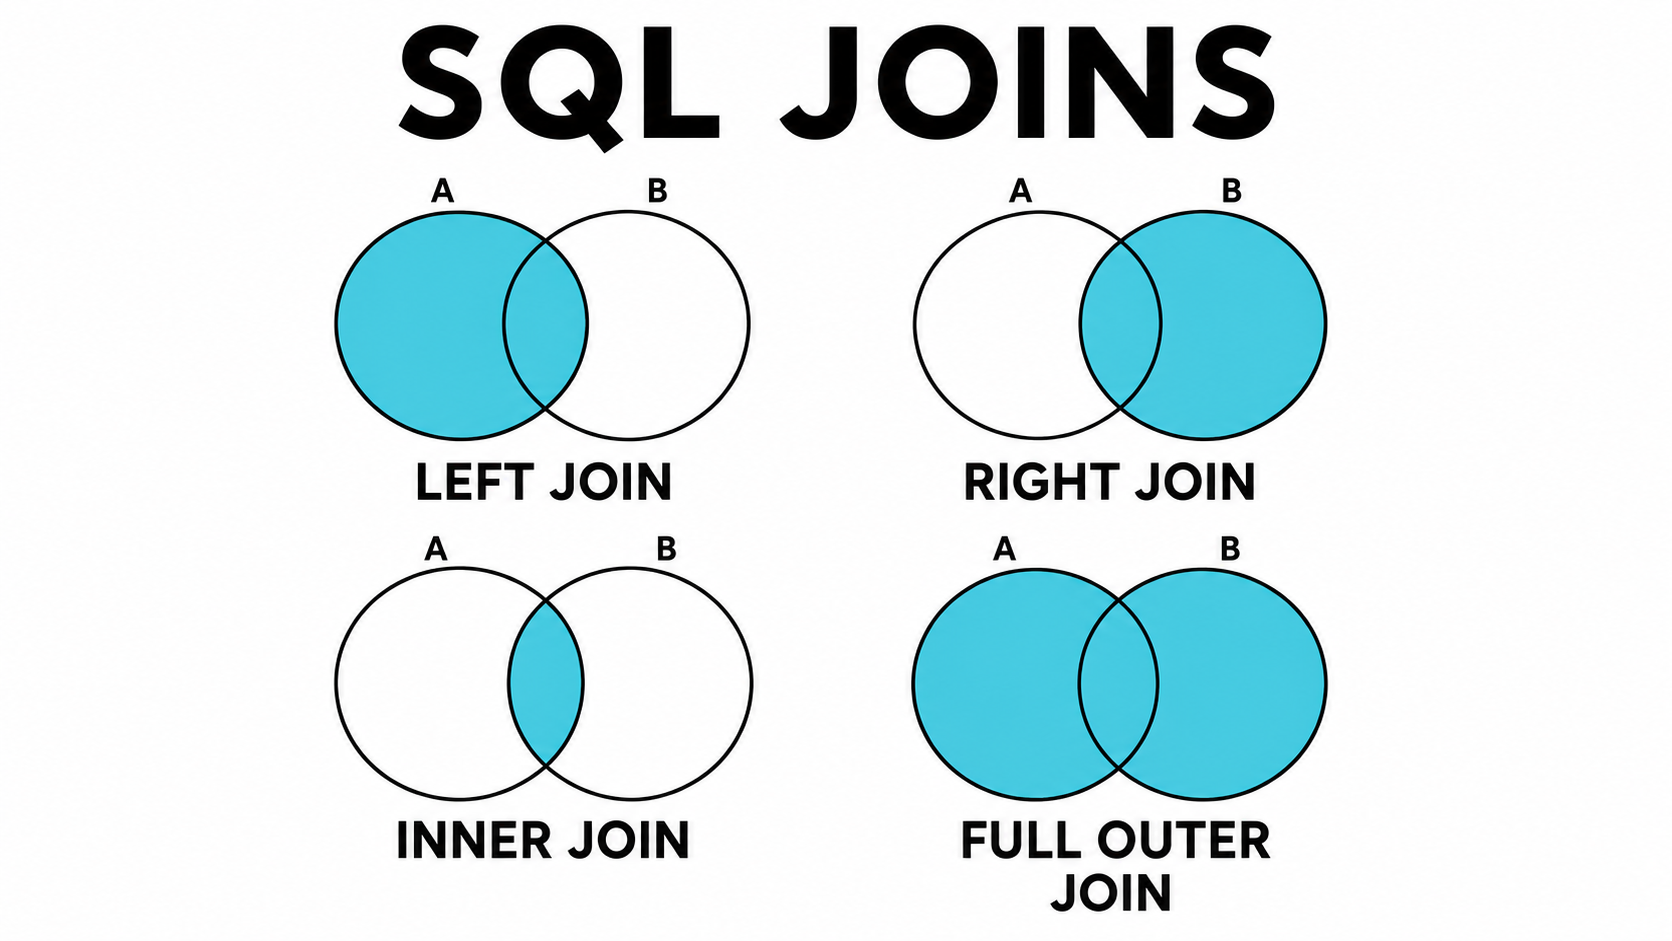

In [ ]:
# ============================================================
# INNER JOIN — Combinar datos hidraulicos con datos de motores
# ============================================================

# Pregunta de mantenimiento:
# "¿Cuando la temperatura del aceite hidraulico es alta,
#  tambien sube la temperatura del motor?"
# Detectar correlaciones entre sistemas es clave en mantenimiento predictivo

join_hyd_mot = con.execute("""
    SELECT
        h.datetime,
        h.Status_Process,
        h.OilTemp AS temp_aceite_C,
        h.PressureA AS presion_A_bar,
        h.HydFlowEfficiency AS efic_flujo_pct,
        m.Motor1Temp AS temp_motor1_C,
        m.Motor2Temp AS temp_motor2_C,
        m.GBTemp AS temp_caja_engranajes_C
    FROM maquina_hidraulica h
    -- INNER JOIN: solo registros con datetime exactamente igual en ambas tablas
    -- Alias h = hidraulica, m = motores
    INNER JOIN maquina_motores m
        ON h.datetime = m.datetime
    WHERE
        h.OilTemp > 0
        AND m.Motor1Temp > 0
    ORDER BY h.datetime
    LIMIT 20
""").fetchdf()

print("INNER JOIN — Hidraulica + Motores (registros coincidentes)")
print("=" * 90)
print(join_hyd_mot.to_string(index=False))
print(f"\nRegistros con datos en ambas tablas: {len(join_hyd_mot)}")
print("\nObserva si temp_aceite_C y temp_motor1_C suben juntas → correlacion termica")


INNER JOIN — Hidraulica + Motores (registros coincidentes)
Empty DataFrame
Columns: [datetime, Status_Process, temp_aceite_C, presion_A_bar, efic_flujo_pct, temp_motor1_C, temp_motor2_C, temp_caja_engranajes_C]
Index: []

Registros con datos en ambas tablas: 0

Observa si temp_aceite_C y temp_motor1_C suben juntas → correlacion termica


In [ ]:
# ============================================================
# LEFT JOIN — Detectar gaps en adquisicion de datos
# ============================================================

# Pregunta de mantenimiento:
# "¿Hay momentos donde tenemos datos hidraulicos pero NO de motores?"
# Gaps en datos = sensores desconectados o fallas de comunicacion

left_join = con.execute("""
    SELECT
        h.datetime,
        h.OilTemp AS temp_aceite,
        h.PressureA AS presion_A,
        -- Estas columnas seran NULL cuando no hay coincidencia en motores
        m.Motor1Temp AS temp_motor1,
        m.GBTemp AS temp_engranajes,
        CASE
            WHEN m.datetime IS NULL THEN 'SIN DATOS MOTOR'
            ELSE 'CON DATOS MOTOR'
        END AS estado_datos
    FROM maquina_hidraulica h
    -- LEFT JOIN: TODOS los registros hidraulicos,
    -- aunque no haya datos de motor en ese timestamp
    LEFT JOIN maquina_motores m
        ON h.datetime = m.datetime
    ORDER BY h.datetime
    LIMIT 25
""").fetchdf()

print("LEFT JOIN — Todos los registros hidraulicos (con o sin datos de motor)")
print("=" * 85)
print(left_join.to_string(index=False))

sin_motor = left_join[left_join['estado_datos'] == 'SIN DATOS MOTOR']
print(f"\nRegistros SIN datos de motor: {len(sin_motor)} de {len(left_join)}")
print("Esto indica gaps en la sincronizacion de sensores")


LEFT JOIN — Todos los registros hidraulicos (con o sin datos de motor)
           datetime  temp_aceite  presion_A  temp_motor1  temp_engranajes    estado_datos
2025-12-10 12:23:49            0          0            0                0 CON DATOS MOTOR
2025-12-10 12:23:50            0          0           99               99 CON DATOS MOTOR
2025-12-10 12:23:50            0          0            0                0 CON DATOS MOTOR
2025-12-10 13:00:00            0          0           99               99 CON DATOS MOTOR
2025-12-10 13:18:08            0          0            0                0 CON DATOS MOTOR
2025-12-10 13:18:08            0          0            0                0 CON DATOS MOTOR
2025-12-10 13:18:09            0          0           99               99 CON DATOS MOTOR
2025-12-10 13:21:05            0          0            0                0 CON DATOS MOTOR
2025-12-10 17:12:23            0          0            0                0 CON DATOS MOTOR
2025-12-11 09:26:19          

In [ ]:
# ============================================================
# JOIN con sensores pH — Analisis de variacion
# ============================================================

# Pregunta de mantenimiento:
# "¿Cual es la diferencia entre pH de entrada y salida?"

ph_analisis = con.execute("""
    SELECT
        fecha,
        hora,
        ph_alimentacion,
        ph_permeado,
        ROUND(ph_alimentacion - ph_permeado, 2) AS delta_ph,
        CASE
            WHEN ABS(ph_alimentacion - ph_permeado) > 1.5
                THEN 'ANOMALIA — Delta pH alto'
            WHEN ph_alimentacion > 9 OR ph_permeado > 9
                THEN 'pH ALCALINO — Revisar dosificacion'
            WHEN ph_alimentacion < 6.5 OR ph_permeado < 6.5
                THEN 'pH ACIDO — Revisar'
            ELSE 'Normal'
        END AS estado_sistema
    FROM sensores_ph
    WHERE ph_alimentacion IS NOT NULL
      AND ph_permeado IS NOT NULL
    ORDER BY fecha, hora
    LIMIT 20
""").fetchdf()

print("Analisis pH — Sistema de Tratamiento de Agua")
print("=" * 80)
print(ph_analisis.to_string(index=False))


Analisis pH — Sistema de Tratamiento de Agua
   fecha     hora  ph_alimentacion  ph_permeado  delta_ph estado_sistema
1/4/2025 00:00:00              7.5          7.5       0.0         Normal
1/4/2025 00:30:00              7.4          7.5      -0.1         Normal
1/4/2025 01:00:00              7.5          7.5       0.0         Normal
1/4/2025 01:30:00              7.4          7.5      -0.1         Normal
1/4/2025 02:00:00              7.3          7.5      -0.2         Normal
1/4/2025 02:30:00              7.2          7.5      -0.3         Normal
1/4/2025 03:00:00              7.1          7.5      -0.4         Normal
1/4/2025 03:30:00              7.1          7.5      -0.4         Normal
1/4/2025 04:00:00              8.4          7.4       1.0         Normal
1/4/2025 04:30:00              8.2          7.4       0.8         Normal
1/4/2025 05:00:00              7.5          7.5       0.0         Normal
1/4/2025 05:30:00              7.2          7.5      -0.3         Normal
1/4/20

### 🏋️ Ejercicio 2.1 — JOIN
Combina `maquina_hidraulica` con `maquina_servicios` usando `datetime` como llave.
Muestra: fecha, temperatura aceite, presión A, y el tiempo restante para el servicio
del paquete hidráulico (`Status_HydPackServiceTimeRem`).
Usa INNER JOIN. Limita a 15 resultados donde OilTemp > 0.


In [ ]:
# EJERCICIO 2.1 — Tu JOIN aqui
ejercicio_2_1 = """
SELECT
    ???
FROM maquina_hidraulica h
??? JOIN maquina_servicios s
    ON h.??? = s.???
WHERE h.??? > 0
LIMIT 15
"""
# print(con.execute(ejercicio_2_1).fetchdf().to_string(index=False))
print("Completa el JOIN con las columnas correctas")


Completa el JOIN con las columnas correctas


---
# 🔧 PARTE 3 — Funciones SQL para Mantenimiento

## Funciones de Fecha
Las fechas son críticas en mantenimiento: MTBF, MTTR, backlog, vencimientos.

| Función (DuckDB) | Equivalente SQL Server | Qué hace |
|------------------|----------------------|----------|
| `DATE_DIFF('day', f1, f2)` | `DATEDIFF(day, f1, f2)` | Días entre fechas |
| `DATE_TRUNC('month', f)` | `DATETRUNC(month, f)` | Truncar a mes |
| `EXTRACT(month FROM f)` | `MONTH(f)` | Extraer componente |
| `STRFTIME(f, '%Y-%m')` | `FORMAT(f, 'yyyy-MM')` | Formatear fecha |

## Funciones Condicionales
| Función | Qué hace | Ejemplo |
|---------|----------|---------|
| `CASE WHEN ... THEN ... END` | Lógica condicional | Clasificar severidad |
| `COALESCE(col, valor)` | Reemplazar NULL | `COALESCE(total_hh, 0)` |
| `NULLIF(col, valor)` | Convertir valor a NULL | Evitar división por cero |
| `ROUND(col, decimales)` | Redondear | `ROUND(avg_hh, 2)` |


In [ ]:
# ============================================================
# FUNCIONES DE FECHA — Duracion real de OTs (base del MTTR)
# ============================================================

# Pregunta de mantenimiento:
# "¿Cuantos dias tardaron las ordenes correctivas en completarse?"
# Esto es la base del calculo de MTTR (Mean Time To Repair)

duracion_ots = con.execute("""
    SELECT
        num_ot,
        descripcion_objeto,
        tipo_trabajo,
        inicio_real,
        fin_real,
        -- DATE_DIFF calcula la diferencia entre dos fechas
        DATE_DIFF('day', inicio_real, fin_real) AS duracion_dias,
        total_hh AS horas_hombre,
        CASE
            WHEN DATE_DIFF('day', inicio_real, fin_real) = 0
                THEN 'Mismo dia'
            WHEN DATE_DIFF('day', inicio_real, fin_real) BETWEEN 1 AND 3
                THEN '1-3 dias'
            WHEN DATE_DIFF('day', inicio_real, fin_real) BETWEEN 4 AND 7
                THEN '4-7 dias'
            ELSE 'Mas de 1 semana'
        END AS categoria_duracion
    FROM ordenes_trabajo
    WHERE inicio_real IS NOT NULL
      AND fin_real IS NOT NULL
      AND tipo_trabajo = 'MC'
      AND total_hh IS NOT NULL
    ORDER BY duracion_dias DESC
    LIMIT 20
""").fetchdf()

print("Duracion de Ordenes Correctivas — Base del MTTR")
print("=" * 85)
print(duracion_ots.to_string(index=False))


Duracion de Ordenes Correctivas — Base del MTTR
  num_ot                                    descripcion_objeto tipo_trabajo inicio_real   fin_real  duracion_dias  horas_hombre categoria_duracion
150246.0                                             AREA MINA           MC  2024-11-27 2024-11-28              1           0.0           1-3 dias
139421.0                                             AREA MINA           MC  2024-09-25 2024-09-26              1           0.0           1-3 dias
149961.0                                                  TUMI           MC  2024-11-25 2024-11-26              1           0.0           1-3 dias
147734.0                                               PORFIDO           MC  2024-11-12 2024-11-13              1           0.0           1-3 dias
148163.0                            SUBESTACIONES (MOVIL / TR)           MC  2024-11-13 2024-11-14              1           0.0           1-3 dias
122531.0                  ARRANCADOR EXTRACTOR TRV 1625 125 HP        

In [ ]:
# ============================================================
# FUNCIONES DE FECHA — Evolucion mensual de OTs
# ============================================================

# Pregunta de mantenimiento:
# "¿Como evoluciono la carga de trabajo mes a mes en 2024?"

evolucion_mensual = con.execute("""
    SELECT
        STRFTIME(inicio_real, '%Y-%m') AS periodo,
        EXTRACT(month FROM inicio_real) AS mes_num,
        tipo_trabajo,
        COUNT(*) AS total_ots,
        ROUND(SUM(total_hh), 1) AS total_horas,
        ROUND(AVG(total_hh), 2) AS promedio_horas
    FROM ordenes_trabajo
    WHERE inicio_real IS NOT NULL
      AND total_hh IS NOT NULL
      AND tipo_trabajo IN ('MP', 'MC')
    GROUP BY periodo, mes_num, tipo_trabajo
    ORDER BY periodo, tipo_trabajo
""").fetchdf()

print("Evolucion Mensual — Preventivo vs Correctivo (2024)")
print("=" * 75)
print(evolucion_mensual.to_string(index=False))
print("\nUn buen programa de mantenimiento tiene:")
print("   - MP (Preventivo) >> MC (Correctivo) en cantidad de OTs")
print("   - Tendencia decreciente de MC a lo largo del anio")


Evolucion Mensual — Preventivo vs Correctivo (2024)
periodo  mes_num tipo_trabajo  total_ots  total_horas  promedio_horas
2024-01        1           MP        111        472.0            4.25
2024-02        2           MP        158        555.0            3.51
2024-03        3           MC          1          0.0            0.00
2024-03        3           MP        144        502.5            3.49
2024-04        4           MC          4          7.0            1.75
2024-04        4           MP        231        653.0            2.83
2024-05        5           MC          3         12.0            4.00
2024-05        5           MP        190        448.0            2.36
2024-06        6           MC         14         97.0            6.93
2024-06        6           MP        180        526.0            2.92
2024-07        7           MC         31         10.0            0.32
2024-07        7           MP        364       1283.0            3.52
2024-08        8           MC         

In [ ]:
# ============================================================
# CASE + COALESCE — Clasificacion y manejo de NULLs
# ============================================================

# Pregunta de mantenimiento:
# "¿Cual es el estado de cumplimiento de horas por OT?"

clasificacion = con.execute("""
    SELECT
        num_ot,
        descripcion_objeto,
        tipo_trabajo,
        -- COALESCE: si total_hh es NULL, usar 0
        COALESCE(total_hh, 0) AS horas_reales,
        COALESCE(hrs_plan, 0) AS horas_plan,
        CASE
            WHEN total_hh IS NULL
                THEN 'Sin registro de horas'
            WHEN total_hh = 0
                THEN 'Sin horas ejecutadas'
            WHEN hrs_plan IS NULL OR hrs_plan = 0
                THEN 'Sin plan de horas'
            WHEN total_hh <= hrs_plan
                THEN 'Dentro del plan'
            WHEN total_hh <= hrs_plan * 1.2
                THEN 'Leve sobrecosto (hasta 20%)'
            ELSE 'Sobrecosto significativo (>20%)'
        END AS estado_cumplimiento,
        CASE
            WHEN hrs_plan > 0 AND total_hh IS NOT NULL
                THEN ROUND((total_hh - hrs_plan) / hrs_plan * 100, 1)
            ELSE NULL
        END AS variacion_pct
    FROM ordenes_trabajo
    WHERE tipo_trabajo IN ('MP', 'MC')
      AND hrs_plan IS NOT NULL
      AND hrs_plan > 0
    ORDER BY variacion_pct DESC NULLS LAST
    LIMIT 20
""").fetchdf()

print("Cumplimiento de Horas Planificadas vs Reales")
print("=" * 85)
print(clasificacion.to_string(index=False))


Cumplimiento de Horas Planificadas vs Reales
  num_ot             descripcion_objeto tipo_trabajo  horas_reales  horas_plan             estado_cumplimiento  variacion_pct
 93191.0 HELICOIDAL 2 PLANTA CONCRETERA           MP          20.0         1.0 Sobrecosto significativo (>20%)         1900.0
124962.0                       PILETA 1           MP          18.0         1.0 Sobrecosto significativo (>20%)         1700.0
120180.0                       PILETA 2           MP          18.0         1.0 Sobrecosto significativo (>20%)         1700.0
138821.0                    BOMBEO MINA           MP          18.0         1.0 Sobrecosto significativo (>20%)         1700.0
138823.0                    BOMBEO MINA           MP          16.0         1.0 Sobrecosto significativo (>20%)         1500.0
141791.0                    BOMBEO MINA           MP          16.0         1.0 Sobrecosto significativo (>20%)         1500.0
145904.0                    BOMBEO MINA           MP          16.0       

In [ ]:
# ============================================================
# Analisis de Sensores MODBUS — Perfil electrico por hora
# ============================================================

# Pregunta de mantenimiento:
# "¿Cual es el perfil de carga electrica del equipo monitoreado?"

perfil_electrico = con.execute("""
    SELECT
        EXTRACT(hour FROM timestamp) AS hora_dia,
        COUNT(*) AS num_mediciones,
        ROUND(AVG(voltage_avg_V), 2) AS voltaje_prom_V,
        ROUND(MIN(voltage_avg_V), 2) AS voltaje_min_V,
        ROUND(MAX(voltage_avg_V), 2) AS voltaje_max_V,
        ROUND(AVG(current_avg_A), 2) AS corriente_prom_A,
        ROUND(AVG(active_power_total_W)/1000, 2) AS potencia_prom_kW,
        ROUND(AVG(power_factor_total_pct), 3) AS factor_potencia_prom,
        CASE
            WHEN AVG(power_factor_total_pct) < 0.85
                THEN 'FP bajo — penalizacion en factura'
            WHEN AVG(power_factor_total_pct) < 0.92
                THEN 'FP aceptable — mejorable'
            ELSE 'FP optimo'
        END AS estado_fp
    FROM sensores_modbus
    WHERE voltage_avg_V > 0
      AND current_avg_A > 0
    GROUP BY hora_dia
    ORDER BY hora_dia
""").fetchdf()

print("Perfil Electrico por Hora del Dia — Sensor MODBUS-RTU")
print("=" * 90)
print(perfil_electrico.to_string(index=False))
print("\nFactor de Potencia < 0.85 genera penalizaciones en la factura electrica")


Perfil Electrico por Hora del Dia — Sensor MODBUS-RTU
 hora_dia  num_mediciones  voltaje_prom_V  voltaje_min_V  voltaje_max_V  corriente_prom_A  potencia_prom_kW  factor_potencia_prom                         estado_fp
        0             144          128.25         127.44         129.42             94.04             28.05                 0.762 FP bajo — penalizacion en factura
        1             144          128.58         127.61         129.56             88.98             23.82                 0.688 FP bajo — penalizacion en factura
        2             143          128.68         127.73         129.39             91.77             21.78                 0.598 FP bajo — penalizacion en factura
        3             144          128.66         127.58         129.43             90.69             20.84                 0.582 FP bajo — penalizacion en factura
        4             144          128.60         127.62         129.46             90.61             20.70                 0.

### 🏋️ Ejercicio 3.1 — Funciones
Usando `sensores_ph`, calcula por fecha:
- Número de mediciones
- Promedio de pH de alimentación
- Promedio de pH de permeado
- Diferencia promedio entre ambos (alimentación - permeado)
- Clasificación: si la diferencia promedio > 0.5 → "Revisar sistema", si no → "Normal"

Ordena por fecha.


In [ ]:
# EJERCICIO 3.1 — Tu consulta aqui
ejercicio_3_1 = """
SELECT
    fecha,
    COUNT(*) AS num_mediciones,
    ROUND(AVG(???), 3) AS ph_alim_prom,
    ROUND(AVG(???), 3) AS ph_perm_prom,
    ROUND(AVG(???) - AVG(???), 3) AS delta_ph,
    CASE
        WHEN ABS(AVG(???) - AVG(???)) > 0.5 THEN 'Revisar sistema'
        ELSE 'Normal'
    END AS estado
FROM sensores_ph
WHERE ???
GROUP BY fecha
ORDER BY fecha
LIMIT 20
"""
# print(con.execute(ejercicio_3_1).fetchdf().to_string(index=False))
print("Completa la consulta con las funciones de agregacion correctas")


Completa la consulta con las funciones de agregacion correctas


---
# 🪟 PARTE 4 — Window Functions (Funciones de Ventana)

## Concepto
Las Window Functions son las funciones más poderosas de SQL para análisis de mantenimiento.
A diferencia de `GROUP BY` que **colapsa** filas, las Window Functions **mantienen** todas
las filas y agregan información calculada sobre una "ventana" de datos.

### Analogía visual
```
Con GROUP BY (colapsa filas):          Con WINDOW FUNCTION (mantiene filas):
┌──────┬──────┬──────┐                 ┌──────┬──────┬──────┬──────────┐
│ OT   │ Actv │  HH  │                 │ OT   │ Actv │  HH  │ RANK_HH  │
├──────┼──────┼──────┤                 ├──────┼──────┼──────┼──────────┤
│ 1001 │ B01  │  2   │  GROUP BY →     │ 1001 │ B01  │  2   │    2     │
│ 1002 │ B01  │  8   │  ┌──────────┐   │ 1002 │ B01  │  8   │    1     │
│ 1003 │ B02  │  1   │  │ B01 │ 10 │   │ 1003 │ B02  │  1   │    2     │
│ 1004 │ B02  │  5   │  │ B02 │  6 │   │ 1004 │ B02  │  5   │    1     │
└──────┴──────┴──────┘  └──────────┘   └──────┴──────┴──────┴──────────┘
                         Perdiste el                  Mantienes el
                         detalle                      detalle + ranking
```

### Sintaxis
```sql
funcion() OVER (
    PARTITION BY columna_agrupacion   -- Como GROUP BY pero sin colapsar filas
    ORDER BY columna_orden            -- Orden dentro de cada particion
)
```

### Funciones disponibles
| Función | Uso en mantenimiento |
|---------|---------------------|
| `ROW_NUMBER()` | Numerar OTs cronológicamente por activo |
| `RANK()` | Ranking de activos por criticidad |
| `LAG(col, n)` | Valor de la fila anterior (falla previa) |
| `LEAD(col, n)` | Valor de la fila siguiente (próxima falla) |
| `SUM() OVER` | Acumulado de horas por activo |
| `AVG() OVER` | Promedio móvil de temperatura |

### Diagrama PARTITION BY
```
Sin PARTITION:                    Con PARTITION BY objeto:
┌──────────────────────────┐      ┌─────────────────┬─────────────────┐
│ Toda la tabla como       │      │ Grupo BOMBA_01  │ Grupo BOMBA_02  │
│ una sola ventana         │      │ OT1  OT2  OT3   │ OT4  OT5        │
└──────────────────────────┘      └─────────────────┴─────────────────┘
ROW_NUMBER: 1, 2, 3, 4, 5         ROW_NUMBER: 1,2,3  │  1,2
```


In [ ]:
# ============================================================
# ROW_NUMBER — Numerar OTs por activo cronologicamente
# ============================================================

# Pregunta de mantenimiento:
# "¿Cual fue la primera, segunda y tercera intervencion de cada activo?"

row_number_ej = con.execute("""
    SELECT
        objeto,
        descripcion_objeto,
        tipo_trabajo,
        inicio_real,
        total_hh,
        -- ROW_NUMBER: numera las OTs de cada activo por fecha
        -- PARTITION BY objeto → reinicia el contador para cada activo
        -- ORDER BY inicio_real → ordena cronologicamente dentro de cada activo
        ROW_NUMBER() OVER (
            PARTITION BY objeto
            ORDER BY inicio_real
        ) AS num_intervencion,
        -- COUNT total de intervenciones del activo
        COUNT(*) OVER (
            PARTITION BY objeto
        ) AS total_intervenciones_activo
    FROM ordenes_trabajo
    WHERE inicio_real IS NOT NULL
      AND objeto IS NOT NULL
      AND tipo_trabajo IN ('MP', 'MC')
    ORDER BY objeto, inicio_real
    LIMIT 30
""").fetchdf()

print("ROW_NUMBER — Historial numerado por activo")
print("=" * 90)
print(row_number_ej.to_string(index=False))
print("\nnum_intervencion=1 es la primera OT del activo en el periodo")
print("Observa como el contador reinicia para cada activo diferente")


ROW_NUMBER — Historial numerado por activo
objeto descripcion_objeto tipo_trabajo inicio_real  total_hh  num_intervencion  total_intervenciones_activo
    43        BOMBEO MINA           MP  2024-05-17       3.0                 1                          211
    43        BOMBEO MINA           MC  2024-05-17       8.0                 2                          211
    43        BOMBEO MINA           MP  2024-05-22       0.0                 3                          211
    43        BOMBEO MINA           MC  2024-05-30       0.0                 4                          211
    43        BOMBEO MINA           MP  2024-06-19       0.0                 5                          211
    43        BOMBEO MINA           MP  2024-07-01      16.0                 7                          211
    43        BOMBEO MINA           MP  2024-07-01       4.0                 8                          211
    43        BOMBEO MINA           MP  2024-07-01       8.0                 6               

In [ ]:
# ============================================================
# LAG — Tiempo entre fallas (base del MTBF)
# ============================================================

# Pregunta de mantenimiento:
# "¿Cuantos dias pasaron entre una falla y la anterior en el mismo activo?"
# Esto es la base del calculo de MTBF (Mean Time Between Failures)

lag_fallas = con.execute("""
    WITH fallas_ordenadas AS (
        SELECT
            objeto,
            descripcion_objeto,
            num_ot,
            inicio_real,
            total_hh,
            ROW_NUMBER() OVER (
                PARTITION BY objeto
                ORDER BY inicio_real
            ) AS num_falla
        FROM ordenes_trabajo
        WHERE tipo_trabajo = 'MC'
          AND inicio_real IS NOT NULL
          AND objeto IS NOT NULL
    )
    SELECT
        objeto,
        descripcion_objeto,
        num_ot,
        inicio_real AS fecha_falla_actual,
        -- LAG obtiene el valor de la fila ANTERIOR dentro de la misma particion
        LAG(inicio_real) OVER (
            PARTITION BY objeto
            ORDER BY inicio_real
        ) AS fecha_falla_anterior,
        DATE_DIFF('day',
            LAG(inicio_real) OVER (PARTITION BY objeto ORDER BY inicio_real),
            inicio_real
        ) AS dias_entre_fallas,
        total_hh AS horas_reparacion,
        num_falla
    FROM fallas_ordenadas
    ORDER BY objeto, inicio_real
    LIMIT 25
""").fetchdf()

print("LAG — Tiempo entre Fallas por Activo (Base del MTBF)")
print("=" * 90)
print(lag_fallas.to_string(index=False))
print("\ndias_entre_fallas = NULL en la primera falla (no hay falla anterior)")
print("MTBF = promedio de dias_entre_fallas por activo")


LAG — Tiempo entre Fallas por Activo (Base del MTBF)
objeto            descripcion_objeto   num_ot fecha_falla_actual fecha_falla_anterior  dias_entre_fallas  horas_reparacion  num_falla
    43                   BOMBEO MINA 116733.0         2024-05-17                  NaT               <NA>               8.0          1
    43                   BOMBEO MINA 118494.0         2024-05-30           2024-05-17                 13               0.0          2
    43                   BOMBEO MINA 145386.0         2024-11-12           2024-05-30                166               0.0          3
    43                   BOMBEO MINA 142982.0         2024-11-26           2024-11-12                 14               0.0          4
    43                   BOMBEO MINA 149366.0         2024-12-03           2024-11-26                  7               0.0          5
  43.1 ESTACIÓN DE BOMBEO NIVEL 1655 141399.0         2024-10-04                  NaT               <NA>               2.0          1
  43.1 ES

In [ ]:
# ============================================================
# RANK — Ranking de activos por criticidad
# ============================================================

# Pregunta de mantenimiento:
# "¿Cuales son los activos mas criticos segun numero de fallas?"

ranking_criticidad = con.execute("""
    WITH metricas_activo AS (
        SELECT
            objeto,
            descripcion_objeto,
            desc_tipo_objeto,
            COUNT(*) AS total_intervenciones,
            SUM(CASE WHEN tipo_trabajo = 'MC' THEN 1 ELSE 0 END) AS num_fallas,
            SUM(CASE WHEN tipo_trabajo = 'MP' THEN 1 ELSE 0 END) AS num_preventivos,
            ROUND(SUM(total_hh), 1) AS total_horas,
            ROUND(AVG(total_hh), 2) AS promedio_horas
        FROM ordenes_trabajo
        WHERE total_hh IS NOT NULL
          AND objeto IS NOT NULL
        GROUP BY objeto, descripcion_objeto, desc_tipo_objeto
    )
    SELECT
        objeto,
        descripcion_objeto,
        desc_tipo_objeto,
        total_intervenciones,
        num_fallas,
        num_preventivos,
        total_horas,
        promedio_horas,
        -- RANK: asigna el mismo numero a empates, salta el siguiente
        RANK() OVER (ORDER BY num_fallas DESC) AS rank_por_fallas,
        RANK() OVER (ORDER BY total_horas DESC) AS rank_por_horas
    FROM metricas_activo
    WHERE num_fallas > 0
    ORDER BY rank_por_fallas
    LIMIT 20
""").fetchdf()

print("RANK — Ranking de Activos por Criticidad")
print("=" * 95)
print(ranking_criticidad.to_string(index=False))
print("\nrank_por_fallas=1 → activo con mas fallas correctivas")
print("Estos activos son candidatos prioritarios para mantenimiento predictivo")


RANK — Ranking de Activos por Criticidad
objeto                                          descripcion_objeto                     desc_tipo_objeto  total_intervenciones  num_fallas  num_preventivos  total_horas  promedio_horas  rank_por_fallas  rank_por_horas
    80                                                   AREA MINA                                 None                   831       110.0             87.0       2352.2            2.83                1               2
    55                                                     PORFIDO                          Estructural                   207        11.0              2.0       1641.0            7.93                2               3
    51                                           PLANTA CONCRETERA                          Estructural                    24        10.0              6.0         50.0            2.08                3              26
    65                                                   DRILLTECH                         

In [ ]:
# ============================================================
# LEAD + LAG — Tendencia de temperatura con ventana temporal
# ============================================================

# Pregunta de mantenimiento:
# "¿Como cambia la temperatura del aceite hidraulico entre mediciones?"
# Detectar tendencias de calentamiento anormal

tendencia_temp = con.execute("""
    SELECT
        datetime,
        OilTemp AS temp_actual_C,
        LAG(OilTemp) OVER (ORDER BY datetime) AS temp_anterior_C,
        LEAD(OilTemp) OVER (ORDER BY datetime) AS temp_siguiente_C,
        OilTemp - LAG(OilTemp) OVER (ORDER BY datetime) AS delta_temp,
        -- Promedio movil de las ultimas 3 mediciones
        AVG(OilTemp) OVER (
            ORDER BY datetime
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        ) AS promedio_movil_3,
        CASE
            WHEN OilTemp - LAG(OilTemp) OVER (ORDER BY datetime) > 5
                THEN 'Calentamiento rapido'
            WHEN OilTemp - LAG(OilTemp) OVER (ORDER BY datetime) > 2
                THEN 'Calentamiento moderado'
            WHEN OilTemp - LAG(OilTemp) OVER (ORDER BY datetime) < -5
                THEN 'Enfriamiento rapido'
            ELSE 'Estable'
        END AS tendencia
    FROM maquina_hidraulica
    WHERE OilTemp > 0
    ORDER BY datetime
    LIMIT 25
""").fetchdf()

print("LEAD/LAG — Tendencia de Temperatura del Aceite Hidraulico")
print("=" * 90)
print(tendencia_temp.to_string(index=False))
print("\ndelta_temp positivo = temperatura subiendo")
print("Calentamiento rapido (>5C entre mediciones) = posible falla inminente")


LEAD/LAG — Tendencia de Temperatura del Aceite Hidraulico
Empty DataFrame
Columns: [datetime, temp_actual_C, temp_anterior_C, temp_siguiente_C, delta_temp, promedio_movil_3, tendencia]
Index: []

delta_temp positivo = temperatura subiendo
Calentamiento rapido (>5C entre mediciones) = posible falla inminente


### 🏋️ Ejercicio 4.1 — Window Functions
Usando `rodamientos`, calcula para cada tipo de falla (`fault`):
- El RMS promedio
- El kurtosis promedio
- El RANK de cada tipo de falla ordenado por kurtosis promedio (mayor = más impactos)

> 💡 Pista: El kurtosis alto indica impactos en el rodamiento → falla más severa


In [ ]:
# EJERCICIO 4.1 — Tu Window Function aqui
ejercicio_4_1 = """
WITH metricas_falla AS (
    SELECT
        fault,
        tipo_falla,
        ROUND(AVG(???), 4) AS rms_promedio,
        ROUND(AVG(???), 4) AS kurtosis_promedio
    FROM rodamientos
    GROUP BY fault, tipo_falla
)
SELECT
    fault,
    tipo_falla,
    rms_promedio,
    kurtosis_promedio,
    RANK() OVER (ORDER BY ??? DESC) AS rank_severidad
FROM metricas_falla
ORDER BY rank_severidad
"""
# print(con.execute(ejercicio_4_1).fetchdf().to_string(index=False))
print("Completa la consulta con las columnas correctas")


Completa la consulta con las columnas correctas


---
# 📊 PARTE 5 — KPIs Reales de Mantenimiento

## Los KPIs más importantes del mantenimiento industrial

Con los datos reales disponibles podemos calcular:

| KPI | Fórmula | Disponible |
|-----|---------|-----------|
| **MTTR** | Promedio duración OTs correctivas | ✅ Con fechas de OTs |
| **Horas acumuladas por activo** | SUM(total_hh) GROUP BY activo | ✅ |
| **Frecuencia de fallas** | COUNT(MC) por activo | ✅ |
| **Evolución mensual** | GROUP BY mes | ✅ |
| **Ranking de activos críticos** | RANK por fallas | ✅ |
| **Perfil eléctrico** | AVG por hora | ✅ (MODBUS) |
| **Alertas de pH** | CASE sobre umbrales | ✅ |
| **Tiempo restante de servicio** | MIN(Status_*ServiceTimeRem) | ✅ (Machine) |
| **Severidad de fallas en rodamientos** | AVG(kurtosis) por tipo | ✅ |

> ⚠️ **KPIs no calculables con estos datos:**
> - **Disponibilidad** → requiere horas de operación total del activo (no disponible en el CSV)
> - **OEE** → requiere producción planificada vs real (no disponible)
> - **Costo por activo** → no hay columna de costo en las OTs


In [ ]:
# ============================================================
# KPI 1 — MTTR (Mean Time To Repair) por tipo de equipo
# ============================================================

# MTTR = Tiempo promedio de reparacion
# Fórmula: Promedio de (fecha_fin - fecha_inicio) para OTs correctivas

mttr = con.execute("""
    SELECT
        desc_tipo_objeto AS tipo_equipo,
        COUNT(*) AS num_fallas,
        ROUND(AVG(DATE_DIFF('day', inicio_real, fin_real)), 2) AS mttr_dias,
        ROUND(AVG(total_hh), 2) AS mttr_hh,
        ROUND(MIN(total_hh), 1) AS min_hh,
        ROUND(MAX(total_hh), 1) AS max_hh
    FROM ordenes_trabajo
    WHERE tipo_trabajo = 'MC'
      AND inicio_real IS NOT NULL
      AND fin_real IS NOT NULL
      AND total_hh IS NOT NULL
      AND desc_tipo_objeto IS NOT NULL
    GROUP BY desc_tipo_objeto
    HAVING COUNT(*) >= 3
    ORDER BY mttr_hh DESC
""").fetchdf()

print("KPI: MTTR (Mean Time To Repair) por Tipo de Equipo")
print("=" * 75)
print(mttr.to_string(index=False))
print("\nMTTR alto = reparaciones largas = mayor impacto en produccion")
print("Priorizar reduccion de MTTR en equipos criticos")


KPI: MTTR (Mean Time To Repair) por Tipo de Equipo
                tipo_equipo  num_fallas  mttr_dias  mttr_hh  min_hh  max_hh
                      Bomba          32       0.00     1.00     0.0    12.0
Sopladores y ventiladores g           6       0.00     1.00     0.0     4.0
              Transformador          20       0.00     0.90     0.0     6.0
                  Electrico          19       0.05     0.68     0.0    10.0
               Perforadoras          15       0.07     0.29     0.0     4.4
                Estructural          26       0.04     0.15     0.0     4.0
         Telecomunicaciones           6       0.00     0.00     0.0     0.0
                Compresores           8       0.00     0.00     0.0     0.0

MTTR alto = reparaciones largas = mayor impacto en produccion
Priorizar reduccion de MTTR en equipos criticos


In [ ]:
# ============================================================
# KPI 2 — Frecuencia de fallas y horas acumuladas por activo
# ============================================================

kpi_activos = con.execute("""
    SELECT
        objeto,
        descripcion_objeto,
        desc_tipo_objeto,
        COUNT(*) AS total_intervenciones,
        SUM(CASE WHEN tipo_trabajo = 'MC' THEN 1 ELSE 0 END) AS num_fallas_MC,
        SUM(CASE WHEN tipo_trabajo = 'MP' THEN 1 ELSE 0 END) AS num_preventivos_MP,
        ROUND(SUM(total_hh), 1) AS horas_acumuladas,
        ROUND(
            SUM(CASE WHEN tipo_trabajo = 'MC' THEN 1.0 ELSE 0 END) /
            NULLIF(SUM(CASE WHEN tipo_trabajo = 'MP' THEN 1.0 ELSE 0 END), 0),
            2
        ) AS ratio_MC_MP,
        CASE
            WHEN SUM(CASE WHEN tipo_trabajo = 'MC' THEN 1 ELSE 0 END) >= 5
                THEN 'CRITICO'
            WHEN SUM(CASE WHEN tipo_trabajo = 'MC' THEN 1 ELSE 0 END) >= 2
                THEN 'IMPORTANTE'
            ELSE 'NORMAL'
        END AS criticidad
    FROM ordenes_trabajo
    WHERE total_hh IS NOT NULL
      AND objeto IS NOT NULL
    GROUP BY objeto, descripcion_objeto, desc_tipo_objeto
    HAVING COUNT(*) >= 5
    ORDER BY num_fallas_MC DESC, horas_acumuladas DESC
    LIMIT 20
""").fetchdf()

print("KPI: Frecuencia de Fallas y Horas Acumuladas por Activo")
print("=" * 95)
print(kpi_activos.to_string(index=False))
print("\nratio_MC_MP > 0.5 = mas correctivo que preventivo → activo problematico")
print("Activos CRITICOS son candidatos prioritarios para mantenimiento predictivo")


KPI: Frecuencia de Fallas y Horas Acumuladas por Activo
objeto                                          descripcion_objeto                     desc_tipo_objeto  total_intervenciones  num_fallas_MC  num_preventivos_MP  horas_acumuladas  ratio_MC_MP criticidad
    80                                                   AREA MINA                                 None                   831          110.0                87.0            2352.2         1.26    CRITICO
    55                                                     PORFIDO                          Estructural                   207           11.0                 2.0            1641.0         5.50    CRITICO
    51                                           PLANTA CONCRETERA                          Estructural                    24           10.0                 6.0              50.0         1.67    CRITICO
    49                                  SUBESTACIONES (MOVIL / TR)                            Electrico                    21       

In [ ]:
# ============================================================
# KPI 3 — Alertas de servicio en maquina perforadora
# ============================================================

# Pregunta de mantenimiento:
# "¿Que componentes de la maquina estan proximos a requerir servicio?"

alertas_servicio = con.execute("""
    WITH ultimo_registro AS (
        SELECT *
        FROM maquina_servicios
        ORDER BY datetime DESC
        LIMIT 1
    )
    SELECT 'Servicio General Maquina' AS componente,
           Status_MachineServiceTimeRem AS horas_restantes
    FROM ultimo_registro
    UNION ALL
    SELECT 'Pernos del Chuck', Status_ChuckBoltsServiceTimeRem FROM ultimo_registro
    UNION ALL
    SELECT 'Chuck', Status_ChuckServiceTimeRem FROM ultimo_registro
    UNION ALL
    SELECT 'Caja Engranajes 1 (1er servicio)', Status_GB1FirstServiceTimeRem FROM ultimo_registro
    UNION ALL
    SELECT 'Caja Engranajes 1 (2do servicio)', Status_GB1SecondServiceTimeRem FROM ultimo_registro
    UNION ALL
    SELECT 'Paquete Hidraulico', Status_HydPackServiceTimeRem FROM ultimo_registro
    UNION ALL
    SELECT 'Motor DC', Status_DCMotorServiceTimeRem FROM ultimo_registro
    UNION ALL
    SELECT 'Sistema de Lubricacion', Status_LubeServiceTimeRem FROM ultimo_registro
""").fetchdf()

def clasificar_alerta(horas):
    if horas == 0:
        return 'VENCIDO — Servicio inmediato'
    elif horas <= 5:
        return 'URGENTE — Proximo a vencer'
    elif horas <= 15:
        return 'ATENCION — Planificar servicio'
    else:
        return 'OK'

alertas_servicio['alerta'] = alertas_servicio['horas_restantes'].apply(clasificar_alerta)
alertas_servicio = alertas_servicio.sort_values('horas_restantes')

print("KPI: Alertas de Servicio — Maquina Perforadora Industrial")
print("=" * 70)
print(alertas_servicio.to_string(index=False))
print("\nEste es el panel de alertas que veria el planificador de mantenimiento")


KPI: Alertas de Servicio — Maquina Perforadora Industrial
                      componente  horas_restantes                       alerta
        Servicio General Maquina                0 VENCIDO — Servicio inmediato
                Pernos del Chuck                0 VENCIDO — Servicio inmediato
                           Chuck                0 VENCIDO — Servicio inmediato
Caja Engranajes 1 (1er servicio)                0 VENCIDO — Servicio inmediato
Caja Engranajes 1 (2do servicio)                0 VENCIDO — Servicio inmediato
              Paquete Hidraulico                0 VENCIDO — Servicio inmediato
                        Motor DC                0 VENCIDO — Servicio inmediato
          Sistema de Lubricacion                0 VENCIDO — Servicio inmediato

Este es el panel de alertas que veria el planificador de mantenimiento


In [ ]:
# ============================================================
# KPI 4 — Analisis de rodamientos: deteccion de fallas
# ============================================================

# Pregunta de mantenimiento:
# "¿Como se diferencian estadisticamente los rodamientos sanos de los fallados?"

analisis_rodamientos = con.execute("""
    SELECT
        tipo_falla,
        fault AS tipo_especifico,
        COUNT(*) AS num_muestras,
        ROUND(AVG(rms), 4) AS rms_prom,
        ROUND(AVG(kurtosis), 4) AS kurtosis_prom,
        ROUND(AVG(crest), 4) AS crest_prom,
        ROUND(AVG(sd), 4) AS desv_std_prom,
        CASE
            WHEN AVG(kurtosis) < 0.5 THEN 'Normal / Sano'
            WHEN AVG(kurtosis) < 2.0 THEN 'Falla incipiente'
            WHEN AVG(kurtosis) < 5.0 THEN 'Falla moderada'
            ELSE 'Falla severa'
        END AS clasificacion_severidad
    FROM rodamientos
    GROUP BY tipo_falla, fault
    ORDER BY tipo_falla, kurtosis_prom DESC
""").fetchdf()

print("KPI: Analisis de Fallas en Rodamientos — Features Estadisticos")
print("=" * 90)
print(analisis_rodamientos.to_string(index=False))
print("\nInterpretacion de tipos de falla:")
print("   Ball = Falla en bola del rodamiento")
print("   IR   = Falla en pista interna (Inner Race)")
print("   OR   = Falla en pista externa (Outer Race)")
print("   Normal = Rodamiento sano (referencia)")
print("\n   Severidad: 007=0.007 pulgadas | 014=0.014 pulgadas | 021=0.021 pulgadas")


KPI: Analisis de Fallas en Rodamientos — Features Estadisticos
tipo_falla tipo_especifico  num_muestras  rms_prom  kurtosis_prom  crest_prom  desv_std_prom clasificacion_severidad
      Ball      Ball_014_1           230    0.1384         2.7388      4.5107         0.1379          Falla moderada
      Ball      Ball_021_1           230    0.2000         0.1181      3.2642         0.1997           Normal / Sano
      Ball      Ball_007_1           230    0.1409        -0.0086      3.3277         0.1396           Normal / Sano
        IR        IR_007_1           230    0.2786         4.3386      5.0222         0.2779          Falla moderada
        IR        IR_014_1           230    0.1971         1.1986      4.3297         0.1946        Falla incipiente
        IR        IR_021_1           230    0.6058         0.7234      3.7728         0.6058        Falla incipiente
    Normal        Normal_1           230    0.0663        -0.0956      3.0940         0.0650           Normal / Sano
 

---
# 🎛️ PARTE 6 — Ejercicios Interactivos

## Consultas dinámicas con ipywidgets

Ahora puedes explorar los datos cambiando parámetros sin modificar el código SQL.


In [ ]:
# ============================================================
# WIDGET INTERACTIVO 1 — Explorador de OTs por tipo de trabajo
# ============================================================

import ipywidgets as widgets
from IPython.display import display, clear_output

tipos_trabajo = con.execute("""
    SELECT DISTINCT tipo_trabajo, desc_tipo_trabajo
    FROM ordenes_trabajo
    WHERE tipo_trabajo IS NOT NULL
    ORDER BY tipo_trabajo
""").fetchdf()

opciones_tipo = {
    f"{row['tipo_trabajo']} — {row['desc_tipo_trabajo']}": row['tipo_trabajo']
    for _, row in tipos_trabajo.iterrows()
}

dropdown_tipo = widgets.Dropdown(
    options=list(opciones_tipo.keys()),
    value=list(opciones_tipo.keys())[0],
    description='Tipo de trabajo:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

slider_hh = widgets.IntSlider(
    value=0, min=0, max=20, step=1,
    description='Min. horas:',
    style={'description_width': 'initial'}
)

slider_limit = widgets.IntSlider(
    value=10, min=5, max=50, step=5,
    description='Mostrar filas:',
    style={'description_width': 'initial'}
)

boton = widgets.Button(
    description='Ejecutar consulta',
    button_style='primary',
    layout=widgets.Layout(width='200px')
)

output = widgets.Output()

def ejecutar_consulta(b):
    with output:
        clear_output()
        tipo_sel = opciones_tipo[dropdown_tipo.value]
        min_hh = slider_hh.value
        limit = slider_limit.value

        resultado = con.execute(f"""
            SELECT
                num_ot,
                descripcion_objeto,
                desc_tipo_objeto,
                org_mant,
                inicio_real,
                total_hh,
                hrs_plan,
                progreso
            FROM ordenes_trabajo
            WHERE tipo_trabajo = '{tipo_sel}'
              AND total_hh >= {min_hh}
              AND total_hh IS NOT NULL
            ORDER BY total_hh DESC
            LIMIT {limit}
        """).fetchdf()

        print(f"\nTipo: {dropdown_tipo.value} | Min. horas: {min_hh} | Filas: {limit}")
        print("=" * 80)
        if len(resultado) > 0:
            print(resultado.to_string(index=False))
            print(f"\nRegistros encontrados: {len(resultado)}")
            print(f"Total HH: {resultado['total_hh'].sum():.1f}")
            print(f"Promedio HH: {resultado['total_hh'].mean():.2f}")
        else:
            print("No se encontraron registros con esos filtros")

boton.on_click(ejecutar_consulta)

print("EXPLORADOR INTERACTIVO DE ORDENES DE TRABAJO")
print("=" * 50)
display(widgets.VBox([dropdown_tipo, slider_hh, slider_limit, boton, output]))


EXPLORADOR INTERACTIVO DE ORDENES DE TRABAJO


In [ ]:
# ============================================================
# AUTOEVALUACION — Preguntas de opcion multiple
# ============================================================

import ipywidgets as widgets
from IPython.display import display, clear_output

preguntas = [
    {
        "pregunta": "¿Que clausula SQL se usa para filtrar GRUPOS despues de un GROUP BY?",
        "opciones": ["WHERE", "HAVING", "FILTER", "CASE"],
        "correcta": "HAVING",
        "explicacion": "HAVING filtra grupos (despues de GROUP BY). WHERE filtra filas individuales (antes de GROUP BY)."
    },
    {
        "pregunta": "¿Que Window Function usarias para obtener el valor de la fila ANTERIOR?",
        "opciones": ["LEAD()", "PREV()", "LAG()", "BEFORE()"],
        "correcta": "LAG()",
        "explicacion": "LAG() obtiene el valor de la fila anterior. LEAD() obtiene el valor de la fila siguiente."
    },
    {
        "pregunta": "¿Que tipo de JOIN devuelve SOLO las filas que coinciden en ambas tablas?",
        "opciones": ["LEFT JOIN", "FULL JOIN", "INNER JOIN", "RIGHT JOIN"],
        "correcta": "INNER JOIN",
        "explicacion": "INNER JOIN devuelve solo las filas con coincidencia en ambas tablas."
    },
    {
        "pregunta": "Para calcular el MTBF necesitas:",
        "opciones": [
            "COUNT(*) de todas las OTs",
            "AVG(total_hh) de OTs correctivas",
            "AVG(dias entre fallas correctivas) por activo",
            "SUM(hrs_plan) de OTs preventivas"
        ],
        "correcta": "AVG(dias entre fallas correctivas) por activo",
        "explicacion": "MTBF = promedio de tiempo entre fallas. Se calcula con LAG() para obtener la fecha de la falla anterior y luego AVG(DATE_DIFF)."
    },
    {
        "pregunta": "¿Que funcion reemplaza NULL por un valor por defecto?",
        "opciones": ["ISNULL()", "COALESCE()", "NULLIF()", "REPLACE()"],
        "correcta": "COALESCE()",
        "explicacion": "COALESCE(col, valor_default) devuelve el primer valor no-NULL. Es estandar SQL."
    }
]

puntaje = [0]
pregunta_actual = [0]
# Use a VBox to contain the dynamic quiz content, and then display it once.
quiz_display_box = widgets.VBox([])
output_quiz = widgets.Output()

def mostrar_pregunta():
    i = pregunta_actual[0]
    if i >= len(preguntas):
        # Quiz completed - display final message
        final_message_content = widgets.Output()
        with final_message_content:
            print(f"\nAutoevaluacion completada!")
            print(f"Puntaje: {puntaje[0]}/{len(preguntas)}")
            if puntaje[0] == len(preguntas):
                print("Perfecto! Dominas los conceptos SQL de mantenimiento")
            elif puntaje[0] >= len(preguntas) * 0.7:
                print("Buen trabajo. Repasa los temas donde fallaste")
            else:
                print("Repasa las secciones del laboratorio y vuelve a intentarlo")
        quiz_display_box.children = [final_message_content] # Update the content of the VBox
        return

    p = preguntas[i]

    question_text = widgets.HTML(
        value=f"<h3>{'='*60}<br>Pregunta {i+1}/{len(preguntas)}<br>{'='*60}<br><br>{p['pregunta']}</h3>",
        layout=widgets.Layout(width='auto')
    )
    radio = widgets.RadioButtons(
        options=p['opciones'],
        layout=widgets.Layout(width='500px')
    )
    boton_resp = widgets.Button(description='Responder', button_style='success')

    def verificar(b):
        feedback_output = widgets.Output()
        with feedback_output:
            if radio.value == p['correcta']:
                puntaje[0] += 1
                print(f"\nCORRECTO! Puntaje: {puntaje[0]}/{i+1}")
            else:
                print(f"\nIncorrecto. La respuesta correcta es: {p['correcta']}")
            print(f"\n{p['explicacion']}")

        pregunta_actual[0] += 1
        boton_sig = widgets.Button(description='Siguiente', button_style='primary')
        boton_sig.on_click(lambda b_next: mostrar_pregunta()) # Use lambda to defer call

        # Update the content of the quiz_display_box with feedback and next button
        quiz_display_box.children = [feedback_output, boton_sig]

    boton_resp.on_click(verificar)

    # Update the content of the quiz_display_box with the current question and options
    quiz_display_box.children = [question_text, radio, boton_resp]

print("AUTOEVALUACION — SQL para Mantenimiento")
print("=" * 45)
print(f"Total de preguntas: {len(preguntas)}")

boton_inicio = widgets.Button(description='Iniciar', button_style='warning')

def iniciar(b):
    with output_quiz:
        clear_output() # Clear the initial message ("Total de preguntas")
        display(quiz_display_box) # Display the main quiz container
    mostrar_pregunta() # Start the first question

boton_inicio.on_click(iniciar)
display(boton_inicio, output_quiz)

AUTOEVALUACION — SQL para Mantenimiento
Total de preguntas: 5


Button(button_style='warning', description='Iniciar', style=ButtonStyle())

Output()

---
# 🏆 PARTE 7 — Ejercicio Integrador Final

## Desafío: Dashboard de Mantenimiento Completo

Usando todo lo aprendido, construye un reporte ejecutivo de mantenimiento.
Este ejercicio integra: SELECT, WHERE, GROUP BY, HAVING, funciones de fecha, CASE y Window Functions.

**Nivel:** Avanzado | **Tiempo estimado:** 20 minutos

**Objetivo:** Crear un reporte que muestre para cada tipo de equipo:
1. Total de OTs ejecutadas
2. Número de fallas correctivas
3. Número de preventivos
4. Total de horas hombre
5. MTTR aproximado (promedio de horas en OTs correctivas)
6. Ratio correctivo/preventivo
7. Clasificación de criticidad (CASE)
8. Ranking por número de fallas (RANK)

**Filtros:** Solo tipos de equipo con al menos 10 OTs, con horas registradas.


In [ ]:
# EJERCICIO INTEGRADOR — Tu solucion aqui
mi_reporte_final = """
SELECT
    ???
FROM ordenes_trabajo
WHERE ???
GROUP BY ???
HAVING ???
ORDER BY ???
"""
# print(con.execute(mi_reporte_final).fetchdf().to_string(index=False))
print("Escribe tu consulta integradora")
print("Usa todo lo aprendido: GROUP BY, HAVING, CASE, RANK()")


Escribe tu consulta integradora
Usa todo lo aprendido: GROUP BY, HAVING, CASE, RANK()


## Exportar datos de DuckDB a CSV para usar en otras bases de datos

In [ ]:
import os

# Directorio donde se guardarán los archivos CSV
output_dir = 'duckdb_exports'
os.makedirs(output_dir, exist_ok=True)

# Ejemplo: Exportar la tabla 'ordenes_trabajo' a un archivo CSV
# La opción HEADER true incluye los nombres de las columnas
# Puedes ajustar el DELIMITER si es necesario
con.execute(f"COPY ordenes_trabajo TO '{output_dir}/ordenes_trabajo.csv' (HEADER true, DELIMITER ',');")

# Puedes repetir esto para cada tabla que quieras exportar
con.execute(f"COPY sensores_modbus TO '{output_dir}/sensores_modbus.csv' (HEADER true, DELIMITER ',');")
con.execute(f"COPY sensores_ph TO '{output_dir}/sensores_ph.csv' (HEADER true, DELIMITER ',');")
con.execute(f"COPY maquina_hidraulica TO '{output_dir}/maquina_hidraulica.csv' (HEADER true, DELIMITER ',');")
con.execute(f"COPY maquina_motores TO '{output_dir}/maquina_motores.csv' (HEADER true, DELIMITER ',');")
con.execute(f"COPY maquina_servicios TO '{output_dir}/maquina_servicios.csv' (HEADER true, DELIMITER ',');")
con.execute(f"COPY rodamientos TO '{output_dir}/rodamientos.csv' (HEADER true, DELIMITER ',');")

print(f"Tablas exportadas a la carpeta '{output_dir}' como archivos CSV.")
print("Puedes descargar estos archivos desde el panel de archivos de Colab.")

Tablas exportadas a la carpeta 'duckdb_exports' como archivos CSV.
Puedes descargar estos archivos desde el panel de archivos de Colab.


Una vez que tengas los archivos CSV, puedes subirlos a tu servidor MySQL y utilizar un comando como `LOAD DATA INFILE` para importarlos en tus tablas MySQL:

```sql
LOAD DATA INFILE '/ruta/a/tu/archivo/ordenes_trabajo.csv'
INTO TABLE tu_base_de_datos.ordenes_trabajo
FIELDS TERMINATED BY ','
ENCLOSED BY '"' -- Si tus campos de texto están encerrados en comillas dobles
LINES TERMINATED BY '\n'
IGNORE 1 ROWS; -- Para ignorar la fila de encabezado
```

Recuerda adaptar la ruta del archivo, el nombre de la base de datos y la tabla según tu configuración en MySQL.

---
# 📚 Resumen del Laboratorio

## Lo que aprendiste hoy

| Concepto | Aplicación en Mantenimiento |
|----------|----------------------------|
| **SELECT / FROM** | Extraer columnas específicas de las OTs |
| **WHERE** | Filtrar por tipo de trabajo, activo, fechas |
| **GROUP BY** | Calcular KPIs por tipo de equipo, organización |
| **HAVING** | Filtrar activos con más de N intervenciones |
| **ORDER BY** | Ranking de activos por criticidad |
| **DISTINCT** | Inventario único de activos |
| **INNER JOIN** | Combinar datos hidráulicos con datos de motores |
| **LEFT JOIN** | Detectar gaps en adquisición de datos |
| **DATE_DIFF** | Calcular MTTR, tiempo entre fallas |
| **CASE / COALESCE** | Clasificar severidad, manejar NULLs |
| **ROW_NUMBER** | Historial numerado de intervenciones |
| **LAG / LEAD** | Tiempo entre fallas (base del MTBF) |
| **RANK** | Ranking de activos críticos |
| **AVG() OVER** | Promedio móvil de temperatura |


## Recursos adicionales

- **DuckDB Documentation:** https://duckdb.org/docs/
- **SQL para Mantenimiento:** Norma ISO 14224 (datos de confiabilidad)
- **CMMS con SQL:** SAP PM, Maximo, Infor EAM — todos usan SQL estándar

---
> 💡 **Recuerda:** El SQL que aprendiste hoy funciona en cualquier motor de base de datos.
> La diferencia entre DuckDB, SQL Server y PostgreSQL son solo pequeños detalles de sintaxis.
> Los conceptos son universales.


---